# **Heart Disease Risk Prediction: Complete ML Workflow**

This workflow predicts whether an individual has heart disease. Because the target is imbalanced, PR-AUC, recall, and F1-score for class 1 are treated as primary evaluation metrics.

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as pe
import plotly.graph_objects as go
from sklearn import set_config
set_config(transform_output='pandas')
from typing import Literal
from pathlib import Path
from scipy.stats import probplot
sns.set_theme('notebook')
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.model_selection import train_test_split,cross_val_predict,cross_val_score,cross_validate,StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as Ppl
from imblearn.model_selection._split import cross_val_predict as Cvp
from imblearn.over_sampling import RandomOverSampler,SVMSMOTE,SMOTE,KMeansSMOTE
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import RobustScaler,OneHotEncoder,OrdinalEncoder
from sklearn.metrics import accuracy_score,precision_score,PrecisionRecallDisplay,ConfusionMatrixDisplay,classification_report,recall_score,f1_score
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier,AdaBoostClassifier,RandomForestClassifier
from sklearn.dummy import DummyClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')
import xgboost as xgb
TARGET='has_heart_disease'
RANDOM_STATE=1

# 1. Data Gathering and Initial Auditing

In [57]:
raw=pd.read_csv(Path('heart_disease_risk_2026.csv'))
feature_informaion=pd.DataFrame(dict(
    Features=raw.columns,
    Missing_Values = raw.isnull().sum().values,
    Missing_Percentage = (raw.isnull().sum()/len(raw)).values,
    Dtype=raw.dtypes.values,
    is_target=[True if raw.columns[i]=='has_heart_disease'
                else False for i in range(len(raw.columns))],
    Uniques=raw.nunique().values,
)).sort_values('Missing_Values',ascending=False);display(feature_informaion)
display(raw.info(),raw.head());display(raw.describe(include='all'),raw.sample(5))
print(f'Distribution : {dict(raw['has_heart_disease'].value_counts())}')

,Features,Missing_Values,Missing_Percentage,Dtype,is_target,Uniques
0,patient_id,0,0.0,int64,False,9000
14,chest_pain_type,0,0.0,object,False,4
25,diet_quality_score,0,0.0,float64,False,763
24,daily_steps,0,0.0,int64,False,5414
23,wearable_owner,0,0.0,bool,False,2
22,stress_score,0,0.0,float64,False,860
21,sleep_hours,0,0.0,float64,False,77
20,exercise_minutes_per_week,0,0.0,int64,False,332
19,alcohol_units_per_week,0,0.0,float64,False,308
18,smoker_status,0,0.0,object,False,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

None

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000,9000,9000.000000,9000.000000,9000.000000,9000.000000,9000,9000.000000,9000.000000,9000.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,3,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,Never,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
freq,NaN,NaN,4731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6548,4980,NaN,NaN,NaN,NaN,5015,NaN,NaN,NaN
mean,4500.500000,53.977333,NaN,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,...,NaN,NaN,5.708733,139.493444,6.994578,47.968033,NaN,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,NaN,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,...,NaN,NaN,5.070642,63.660433,1.104215,16.162484,NaN,2170.685995,14.476064,0.459581
min,1.000000,18.000000,NaN,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,...,NaN,NaN,0.000000,0.000000,3.100000,0.000000,NaN,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,NaN,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,...,NaN,NaN,2.200000,96.000000,6.300000,37.100000,NaN,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,NaN,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,...,NaN,NaN,4.200000,139.000000,7.000000,48.100000,NaN,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,NaN,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,...,NaN,NaN,7.700000,183.000000,7.700000,58.900000,NaN,7632.750000,69.100000,1.000000


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
3314,3315,64,Female,120,77,214,61,124,125,94,...,True,Never,2.8,118,7.0,50.4,False,5095,85.3,1
145,146,74,Female,130,72,226,60,118,245,113,...,False,Never,4.3,161,7.9,96.7,True,5822,52.7,0
1453,1454,63,Male,135,89,235,50,159,57,78,...,True,Current,3.1,99,8.1,77.6,False,4125,42.8,1
2425,2426,60,Female,144,86,204,74,119,48,153,...,False,Never,0.6,130,7.4,40.7,False,5828,53.9,0
7736,7737,73,Male,132,96,177,47,98,135,147,...,False,Never,2.4,146,7.3,66.1,True,7043,55.8,0


Distribution : {0: np.int64(6273), 1: np.int64(2727)}


**Conclusion**

1) Found Extreme Values in bp , cholesterol hdl , ldl and almost every numerical column representing variation between having heart disease or not. Since they are legitimate , we wont be dropping or capping it.

2) target feature is imbalance with ratio 0:1 = 6273:2727 , required to use SMOTE or Classweights.

3) Also patient_id is a unique identifier for each patient, we will be dropping it.

# 2. Initial Data Cleaning and Validation

In [58]:
def Dropper(col,index=False,data:pd.DataFrame=raw):
    if index : return data.drop(index=col)
    else : return data.drop(columns=col)
df=Dropper(col='patient_id')
feature_info=Dropper(index=True,col=0,data=feature_informaion)
required={*raw.columns.drop(labels='patient_id')}
assert required.issubset(df)
assert df.select_dtypes(include='number').any().all()>0
assert df.isnull().sum().all()==0
print(f'Validation Shape : {df.shape}')
print(f'Validation | Passed')

Validation Shape : (9000, 26)
Validation | Passed


# 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate


 - - - age's Summary - - - 
Dtype : int64
Variance : 169.21
Skewness : -0.02

 - - - sex's Summary - - - 
Dtype : object

 Proportion : 
 sex
Male      52.566667
Female    47.433333
Name: proportion, dtype: float64


 - - - resting_bp_systolic's Summary - - - 
Dtype : int64
Variance : 189.54
Skewness : 0.07

 - - - resting_bp_diastolic's Summary - - - 
Dtype : int64
Variance : 119.68
Skewness : 0.01

 - - - cholesterol_total's Summary - - - 
Dtype : int64
Variance : 1041.46
Skewness : 0.00

 - - - hdl's Summary - - - 
Dtype : int64
Variance : 153.62
Skewness : 0.02

 - - - ldl's Summary - - - 
Dtype : int64
Variance : 747.60
Skewness : 0.04

 - - - triglycerides's Summary - - - 
Dtype : int64
Variance : 2646.94
Skewness : 0.13

 - - - fasting_blood_sugar's Summary - - - 
Dtype : int64
Variance : 518.84
Skewness : 0.04

 - - - hba1c's Summary - - - 
Dtype : float64
Variance : 0.48
Skewness : 0.03

 - - - bmi's Summary - - - 
Dtype : float64
Variance : 19.11
Skewness : 0.09

 - - - rest

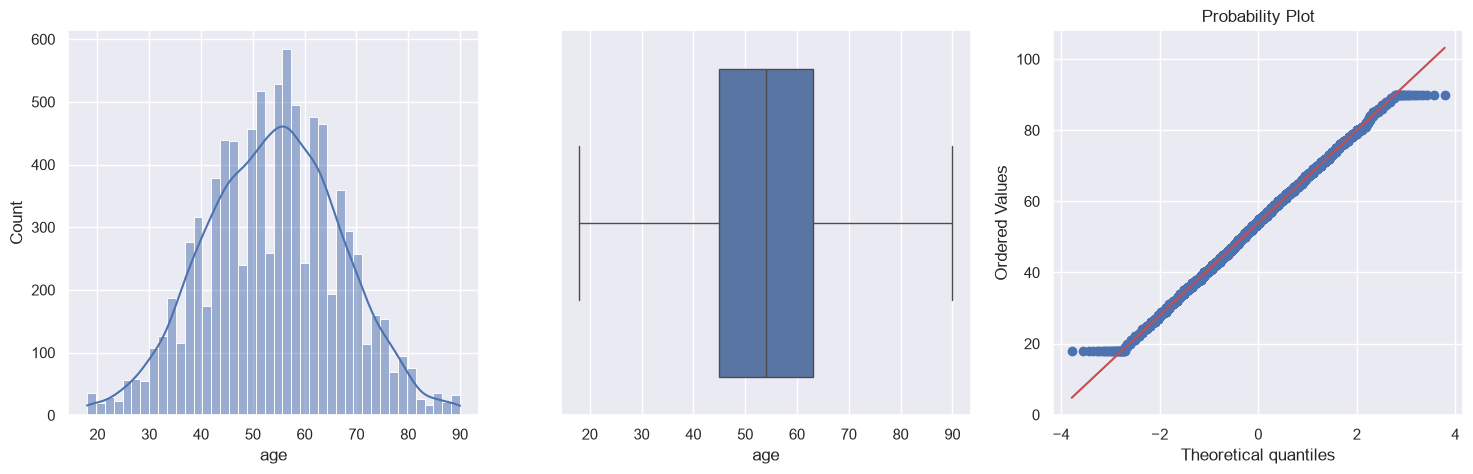

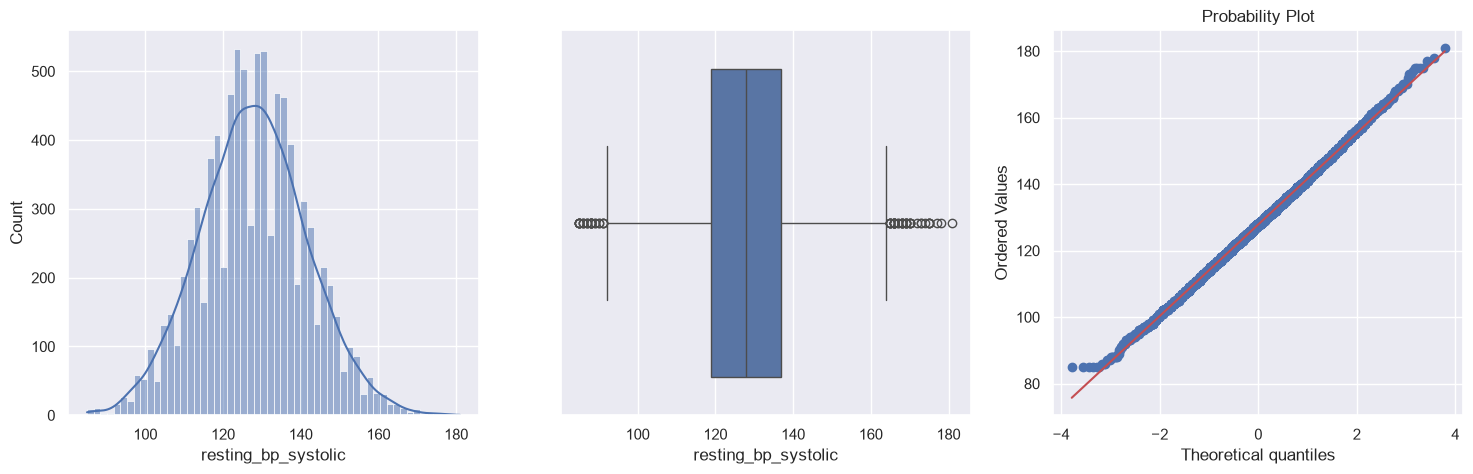

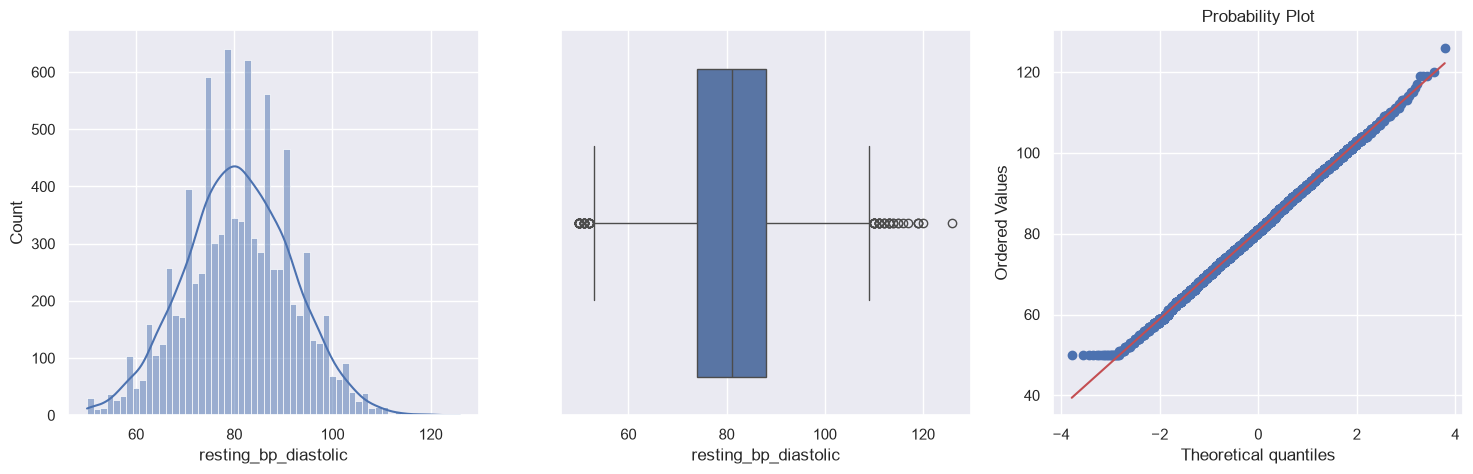

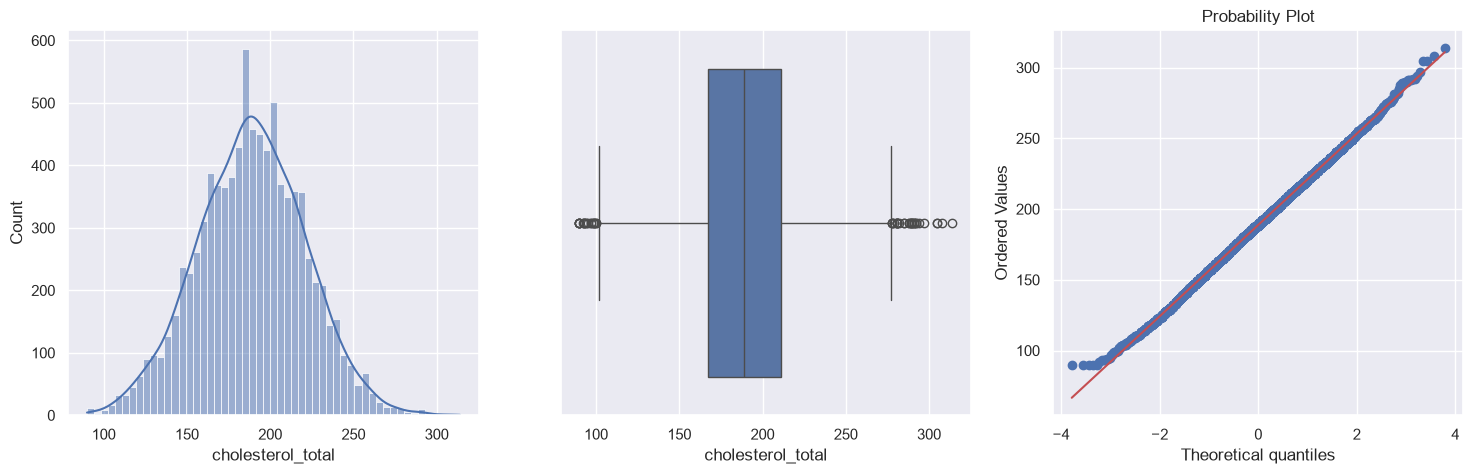

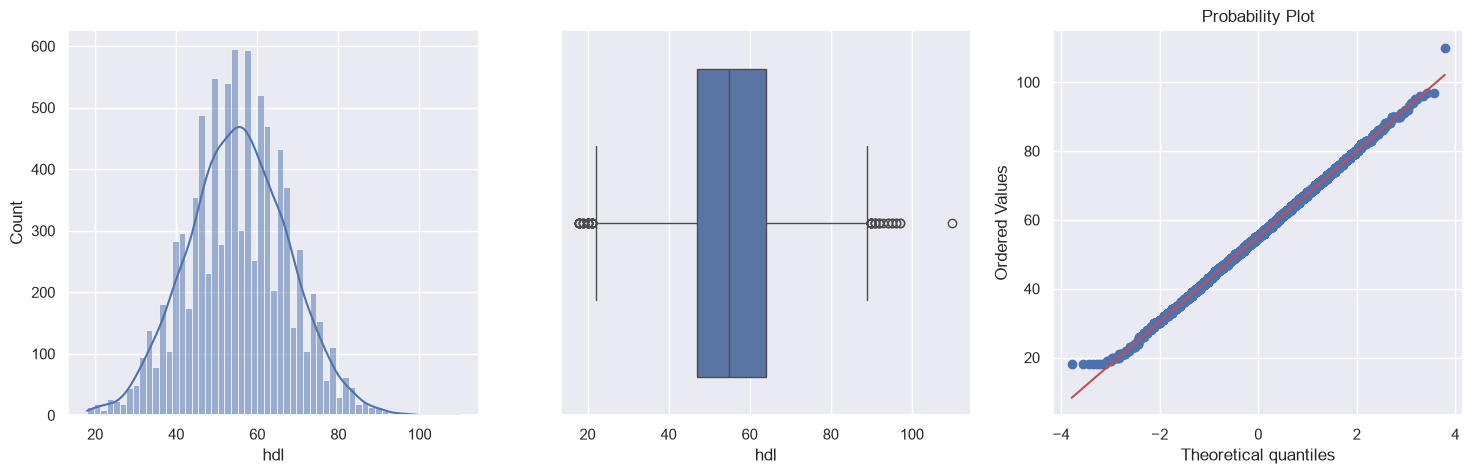

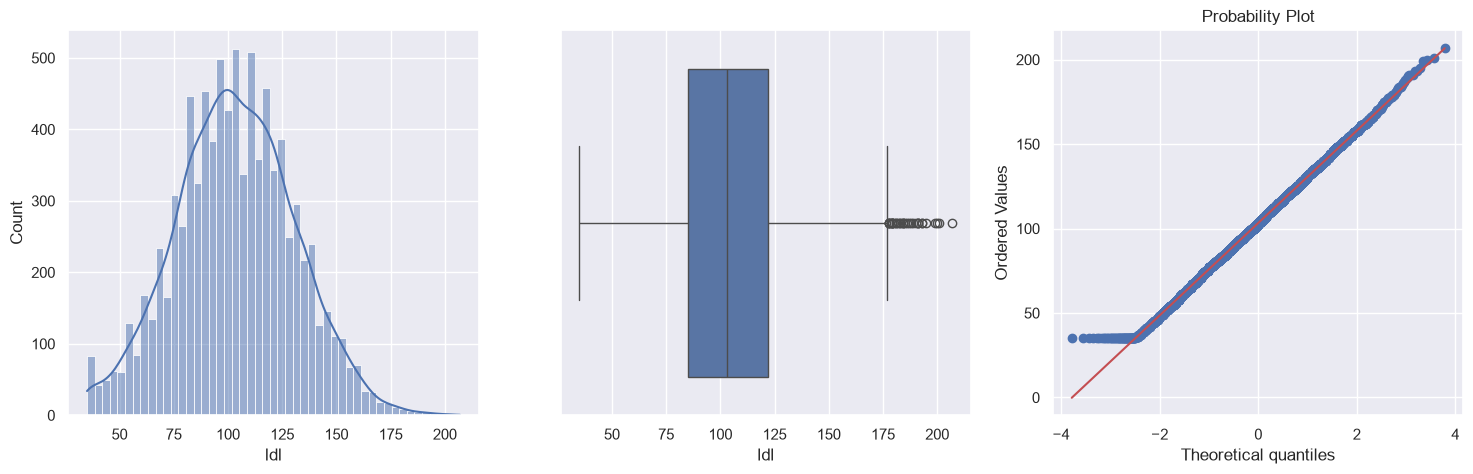

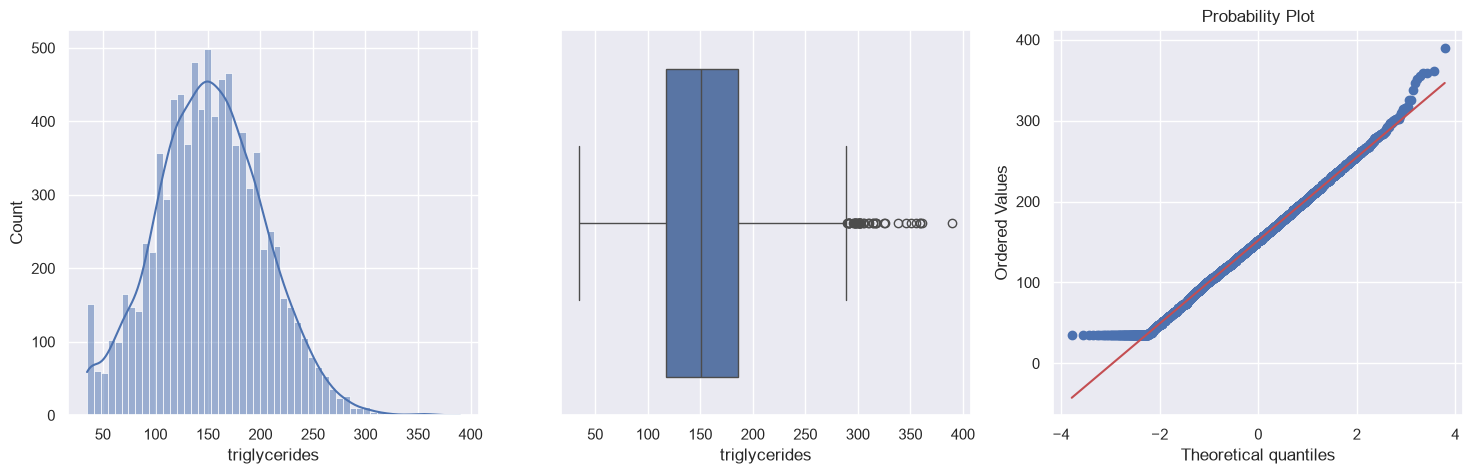

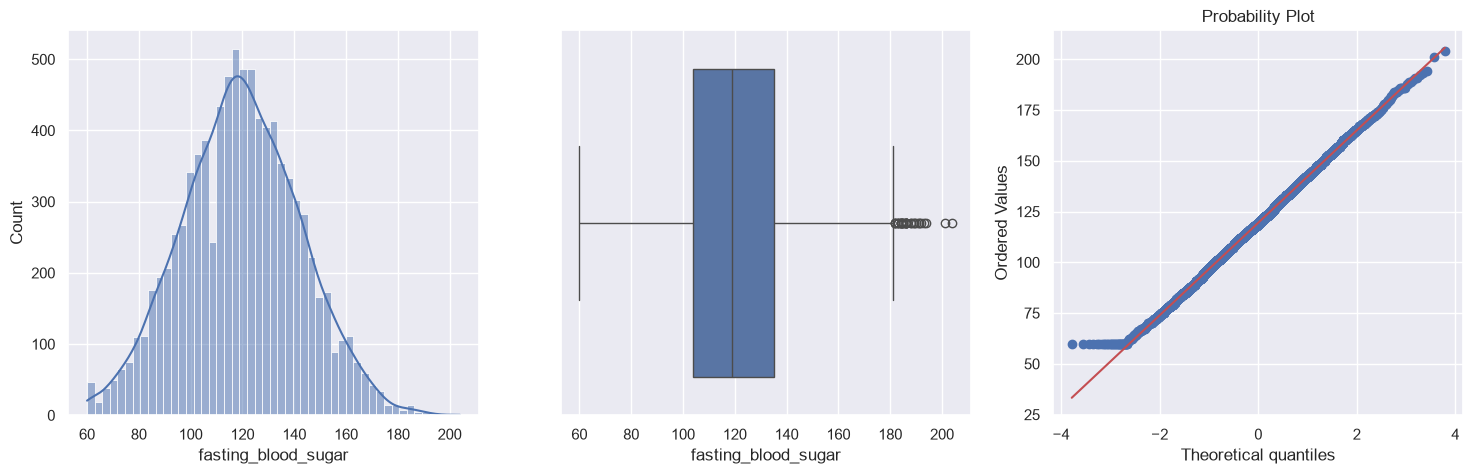

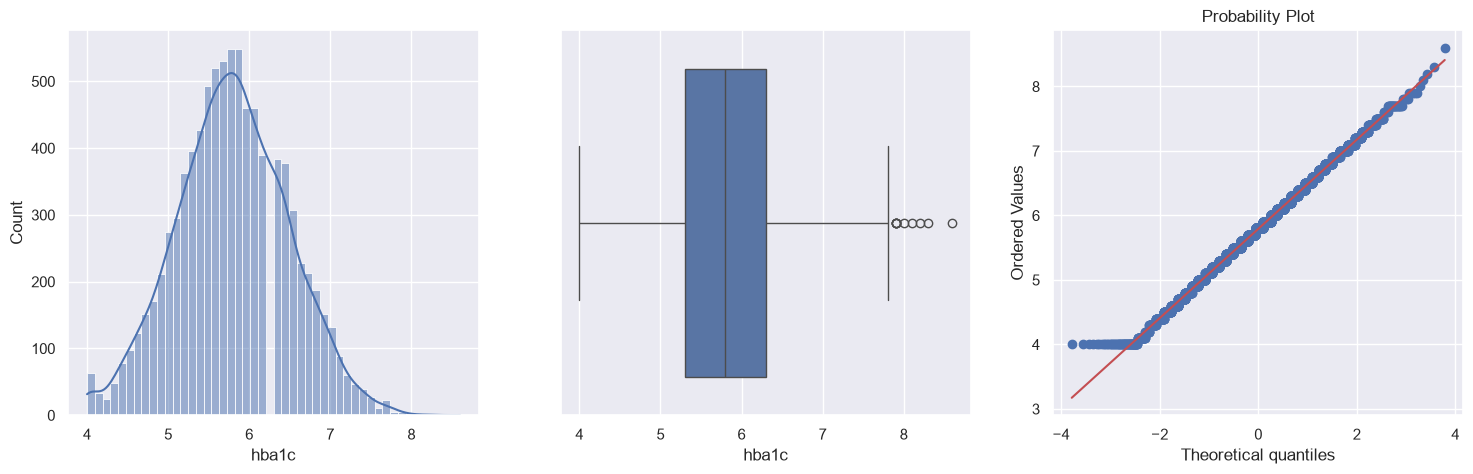

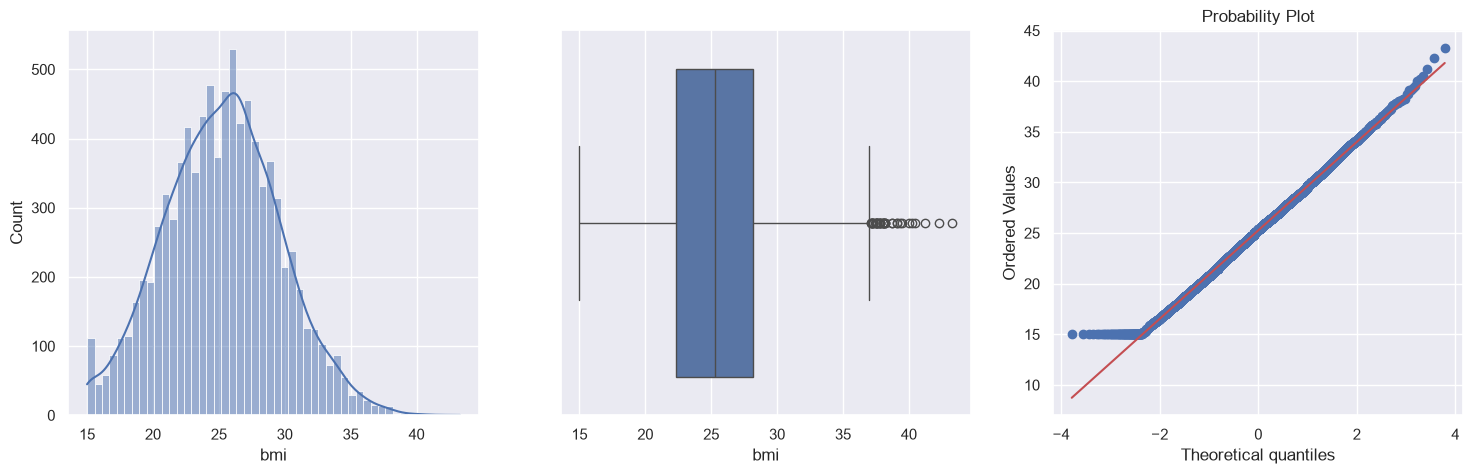

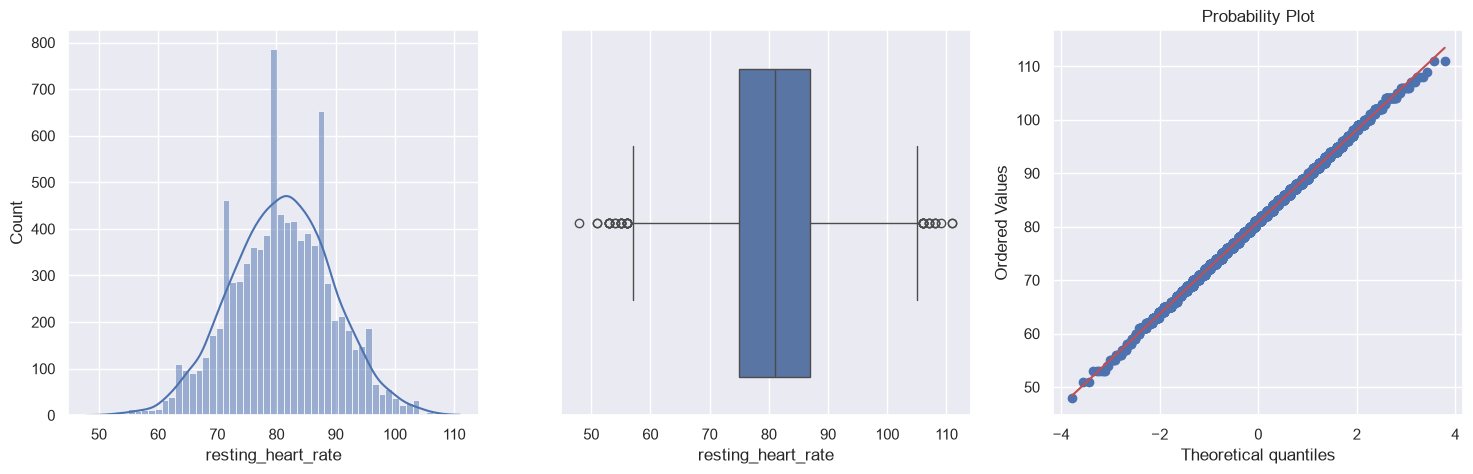

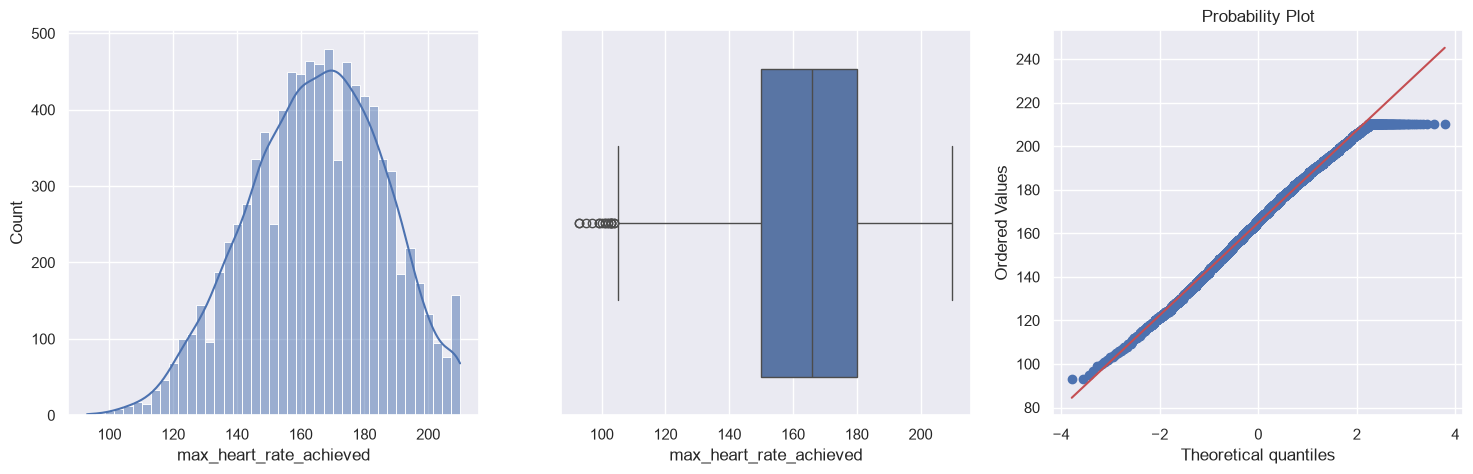

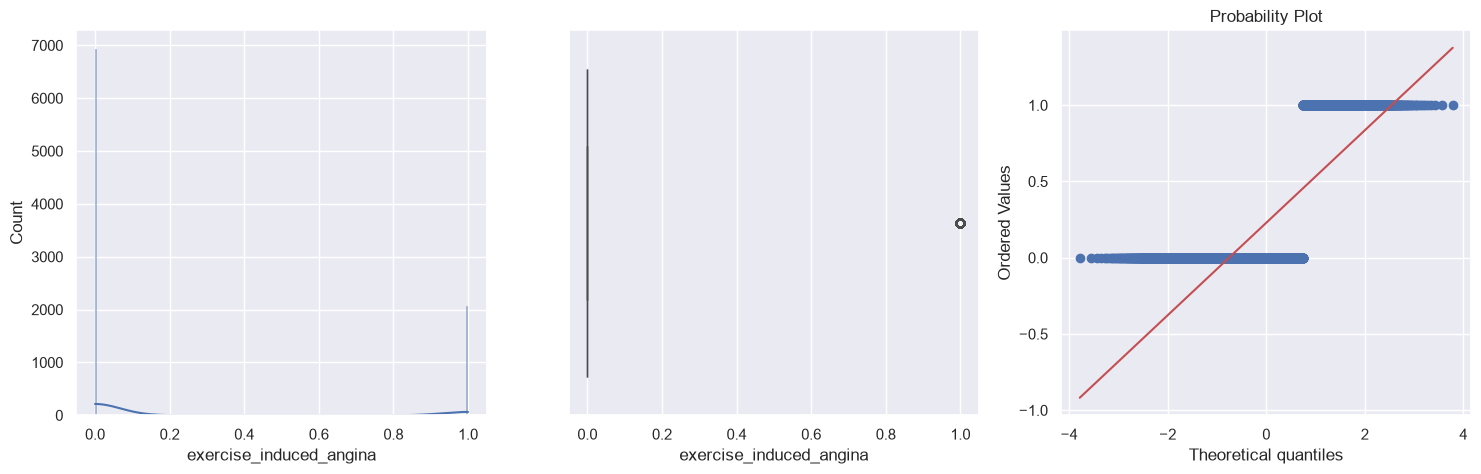

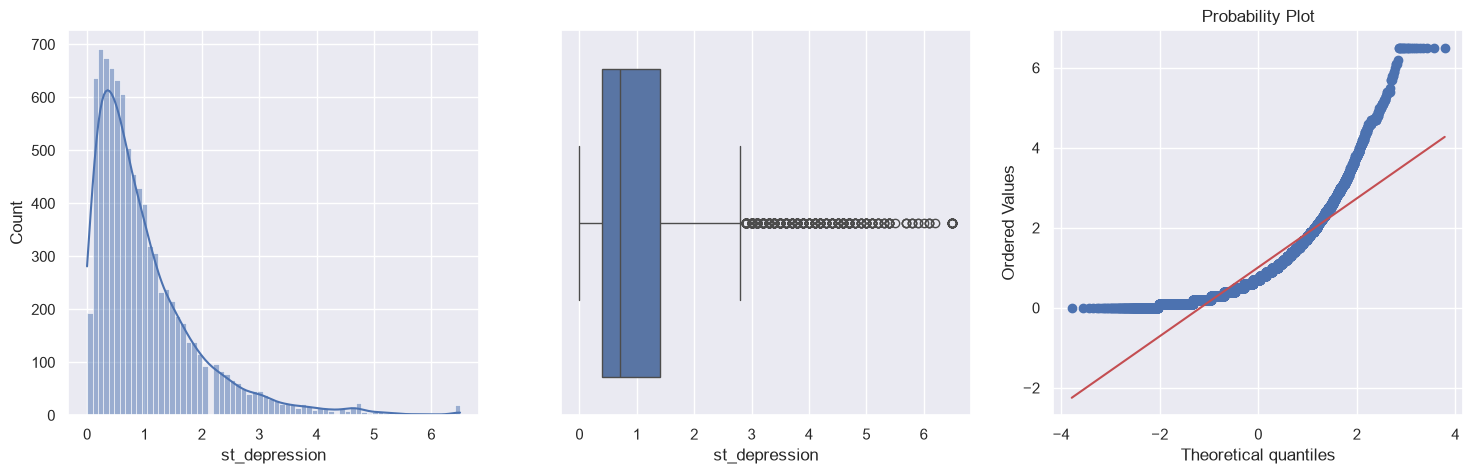

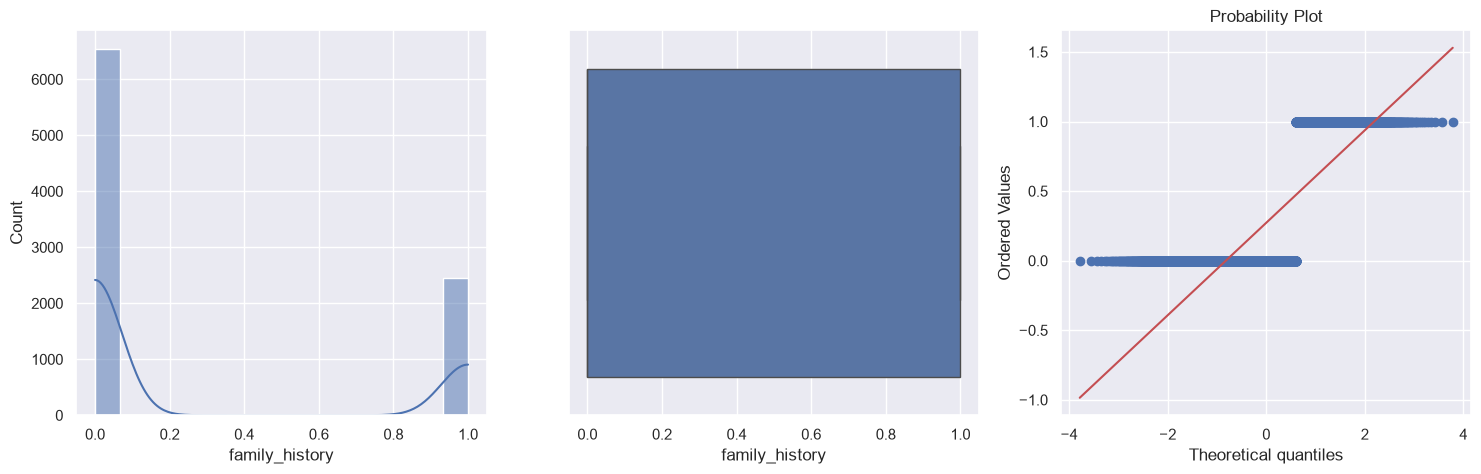

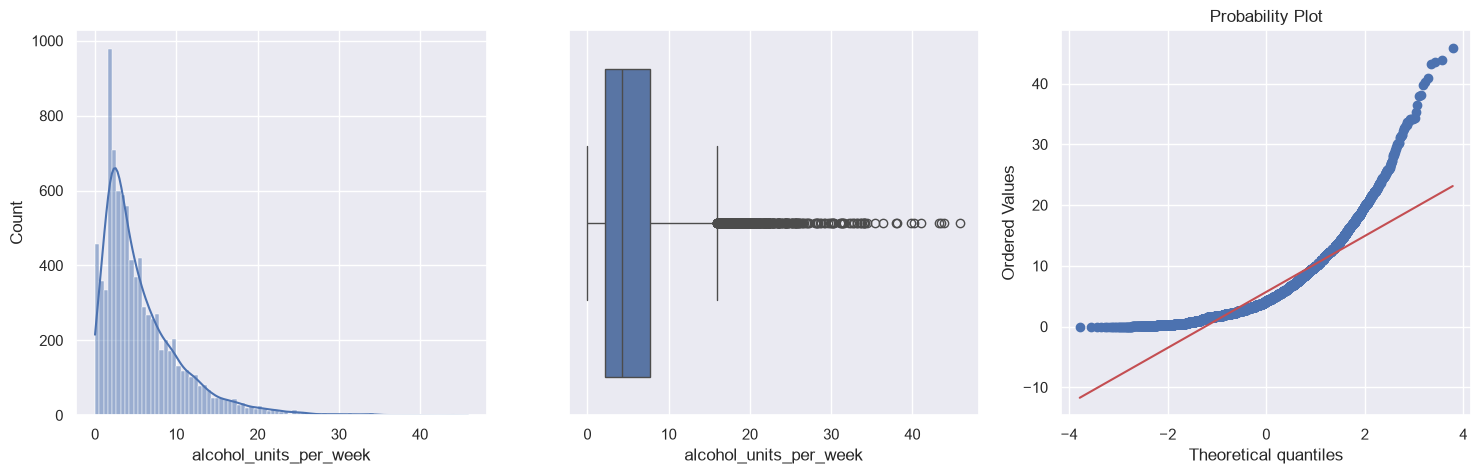

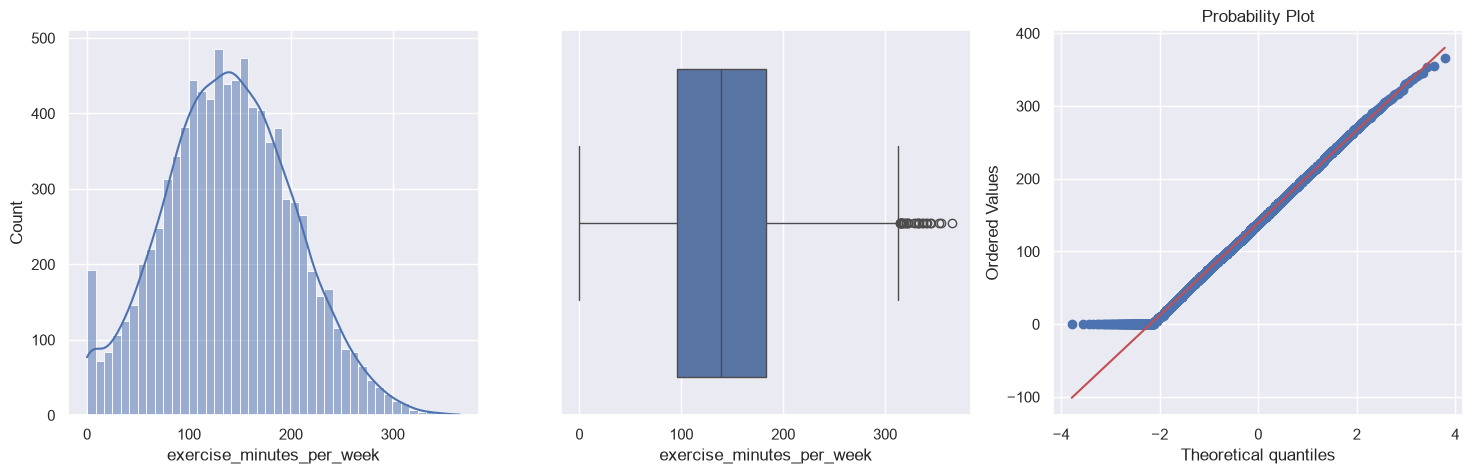

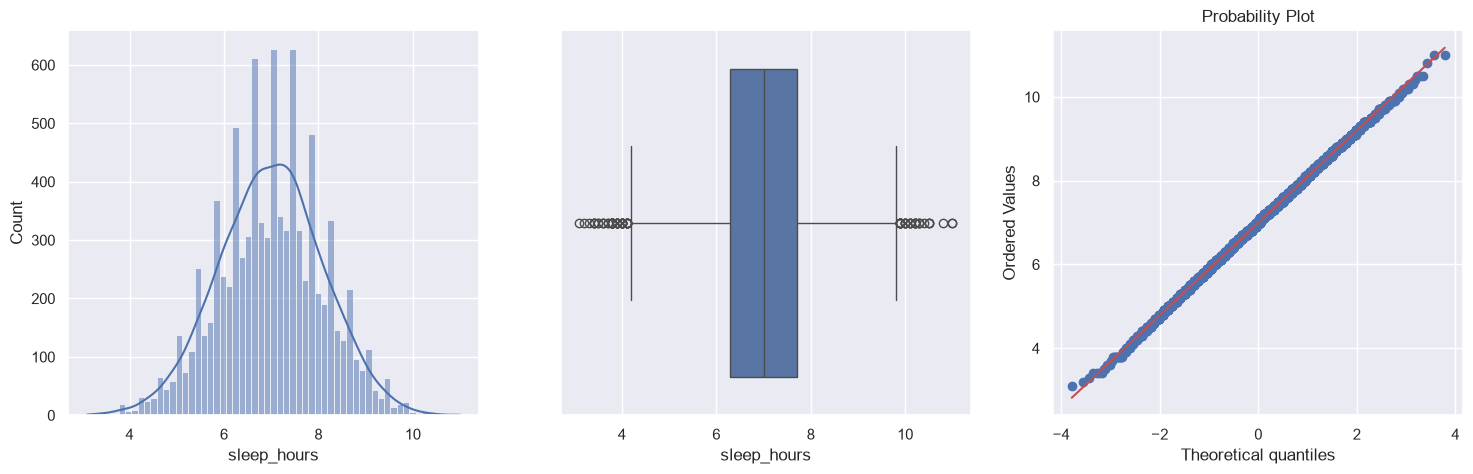

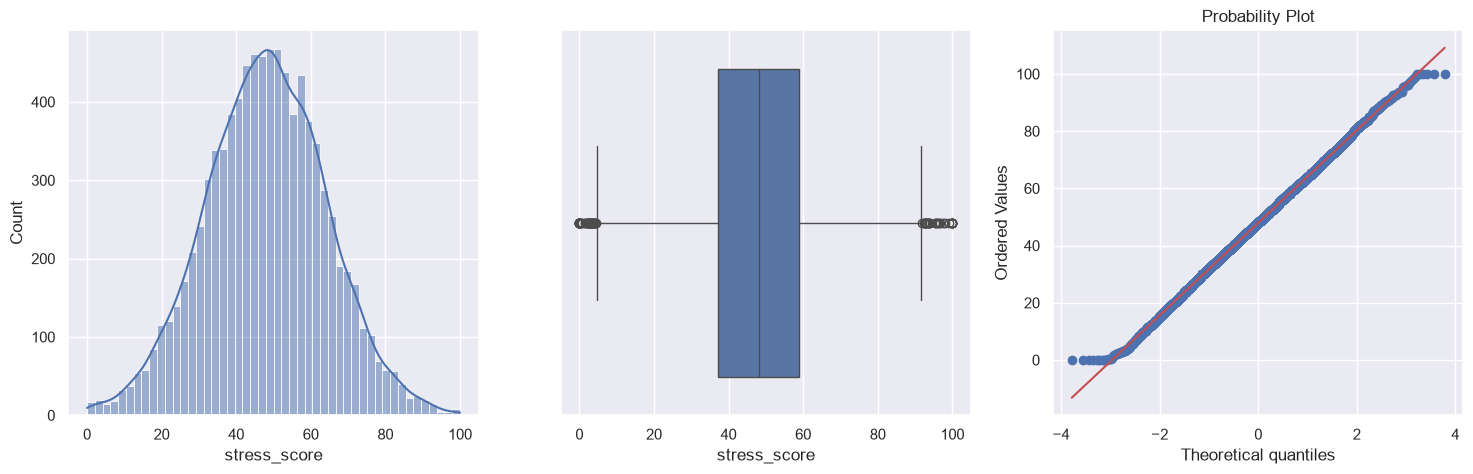

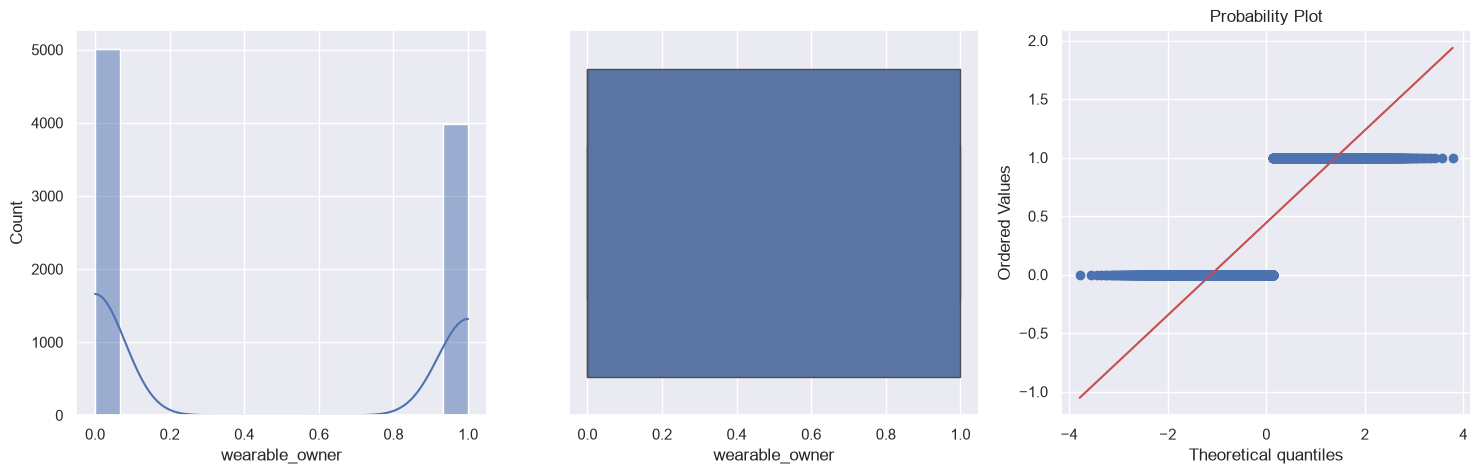

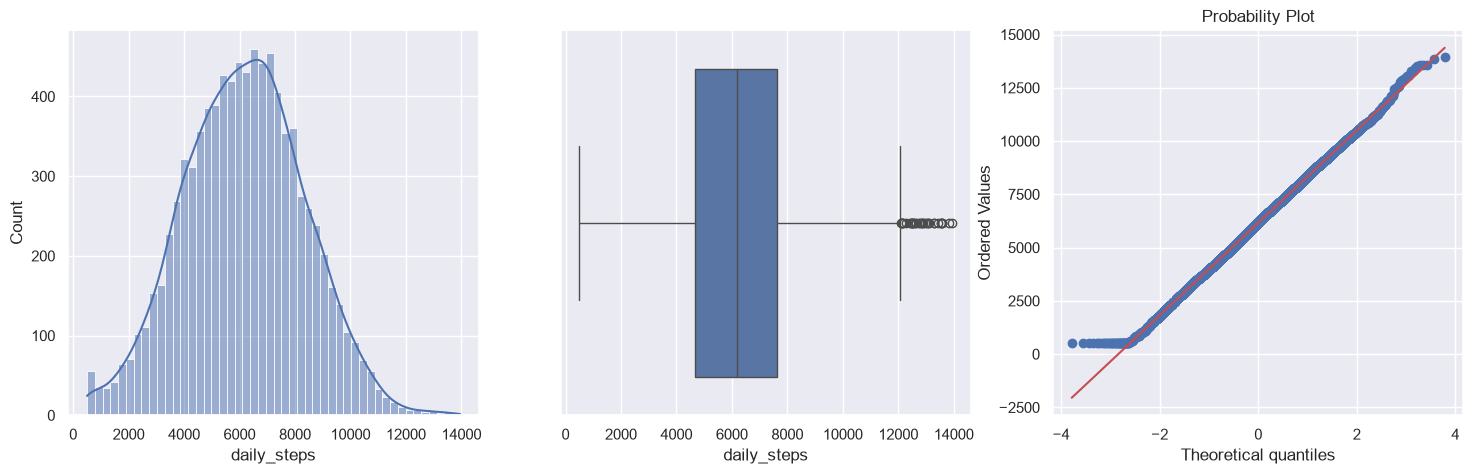

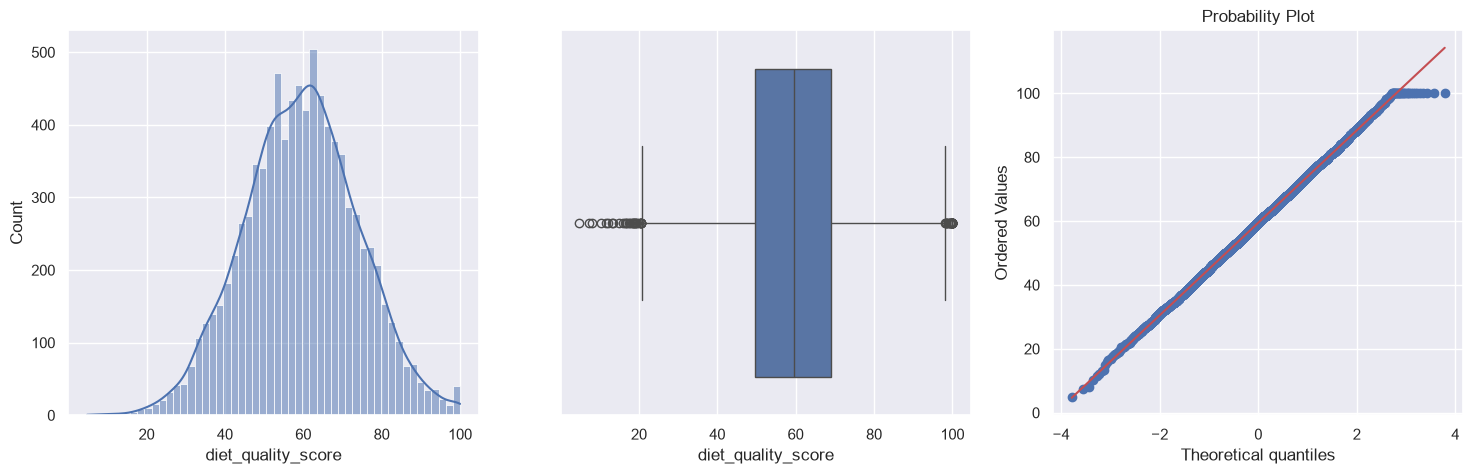

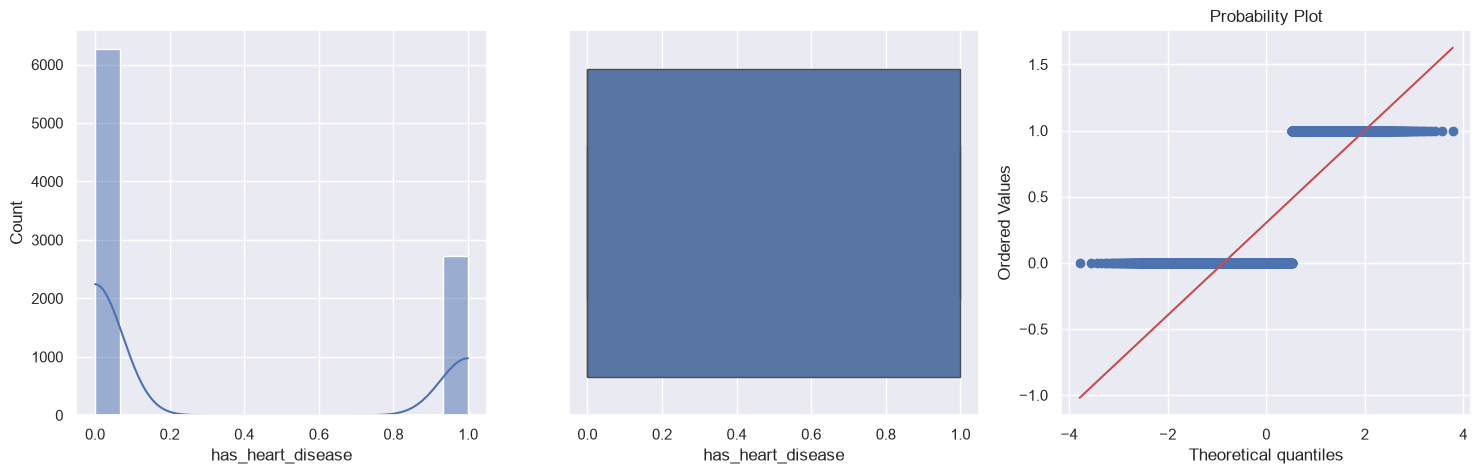

In [59]:
def Univariate(col):
    if df[col].dtype == object:
        print(f'\n - - - {col}\'s Summary - - - ')
        print(f'Dtype : {df[col].dtype}')
        print(f'\n Proportion : \n {df[col].value_counts(normalize=True)*100}\n')
    else:
        print(f'\n - - - {col}\'s Summary - - - ')
        print(f'Dtype : {df[col].dtype}')
        print(f'Variance : {df[col].var():.2f}')
        print(f'Skewness : {df[col].skew():.2f}')
        fig,ax=plt.subplots(1,3,figsize=(18,5))
        sns.histplot(data=df,x=col,kde=True,ax=ax[0])
        sns.boxplot(data=df,x=col,ax=ax[1])
        probplot(x=df[col],dist='norm',plot=ax[2])
for i,v in enumerate(df.columns):
    Univariate(v)

**Conclusion**

1) Almost All of numerical columns are normally distributed(approx) as it skewness is within range of -0.5 to 0.5. We can call them as normally distributed.this is the reason for outliers in them.

2) found most people fall after the healthy ranges of every reading unit according to health measurements.

3) Found Chest pain type being ordinal column.

### 3.2 Bivariate

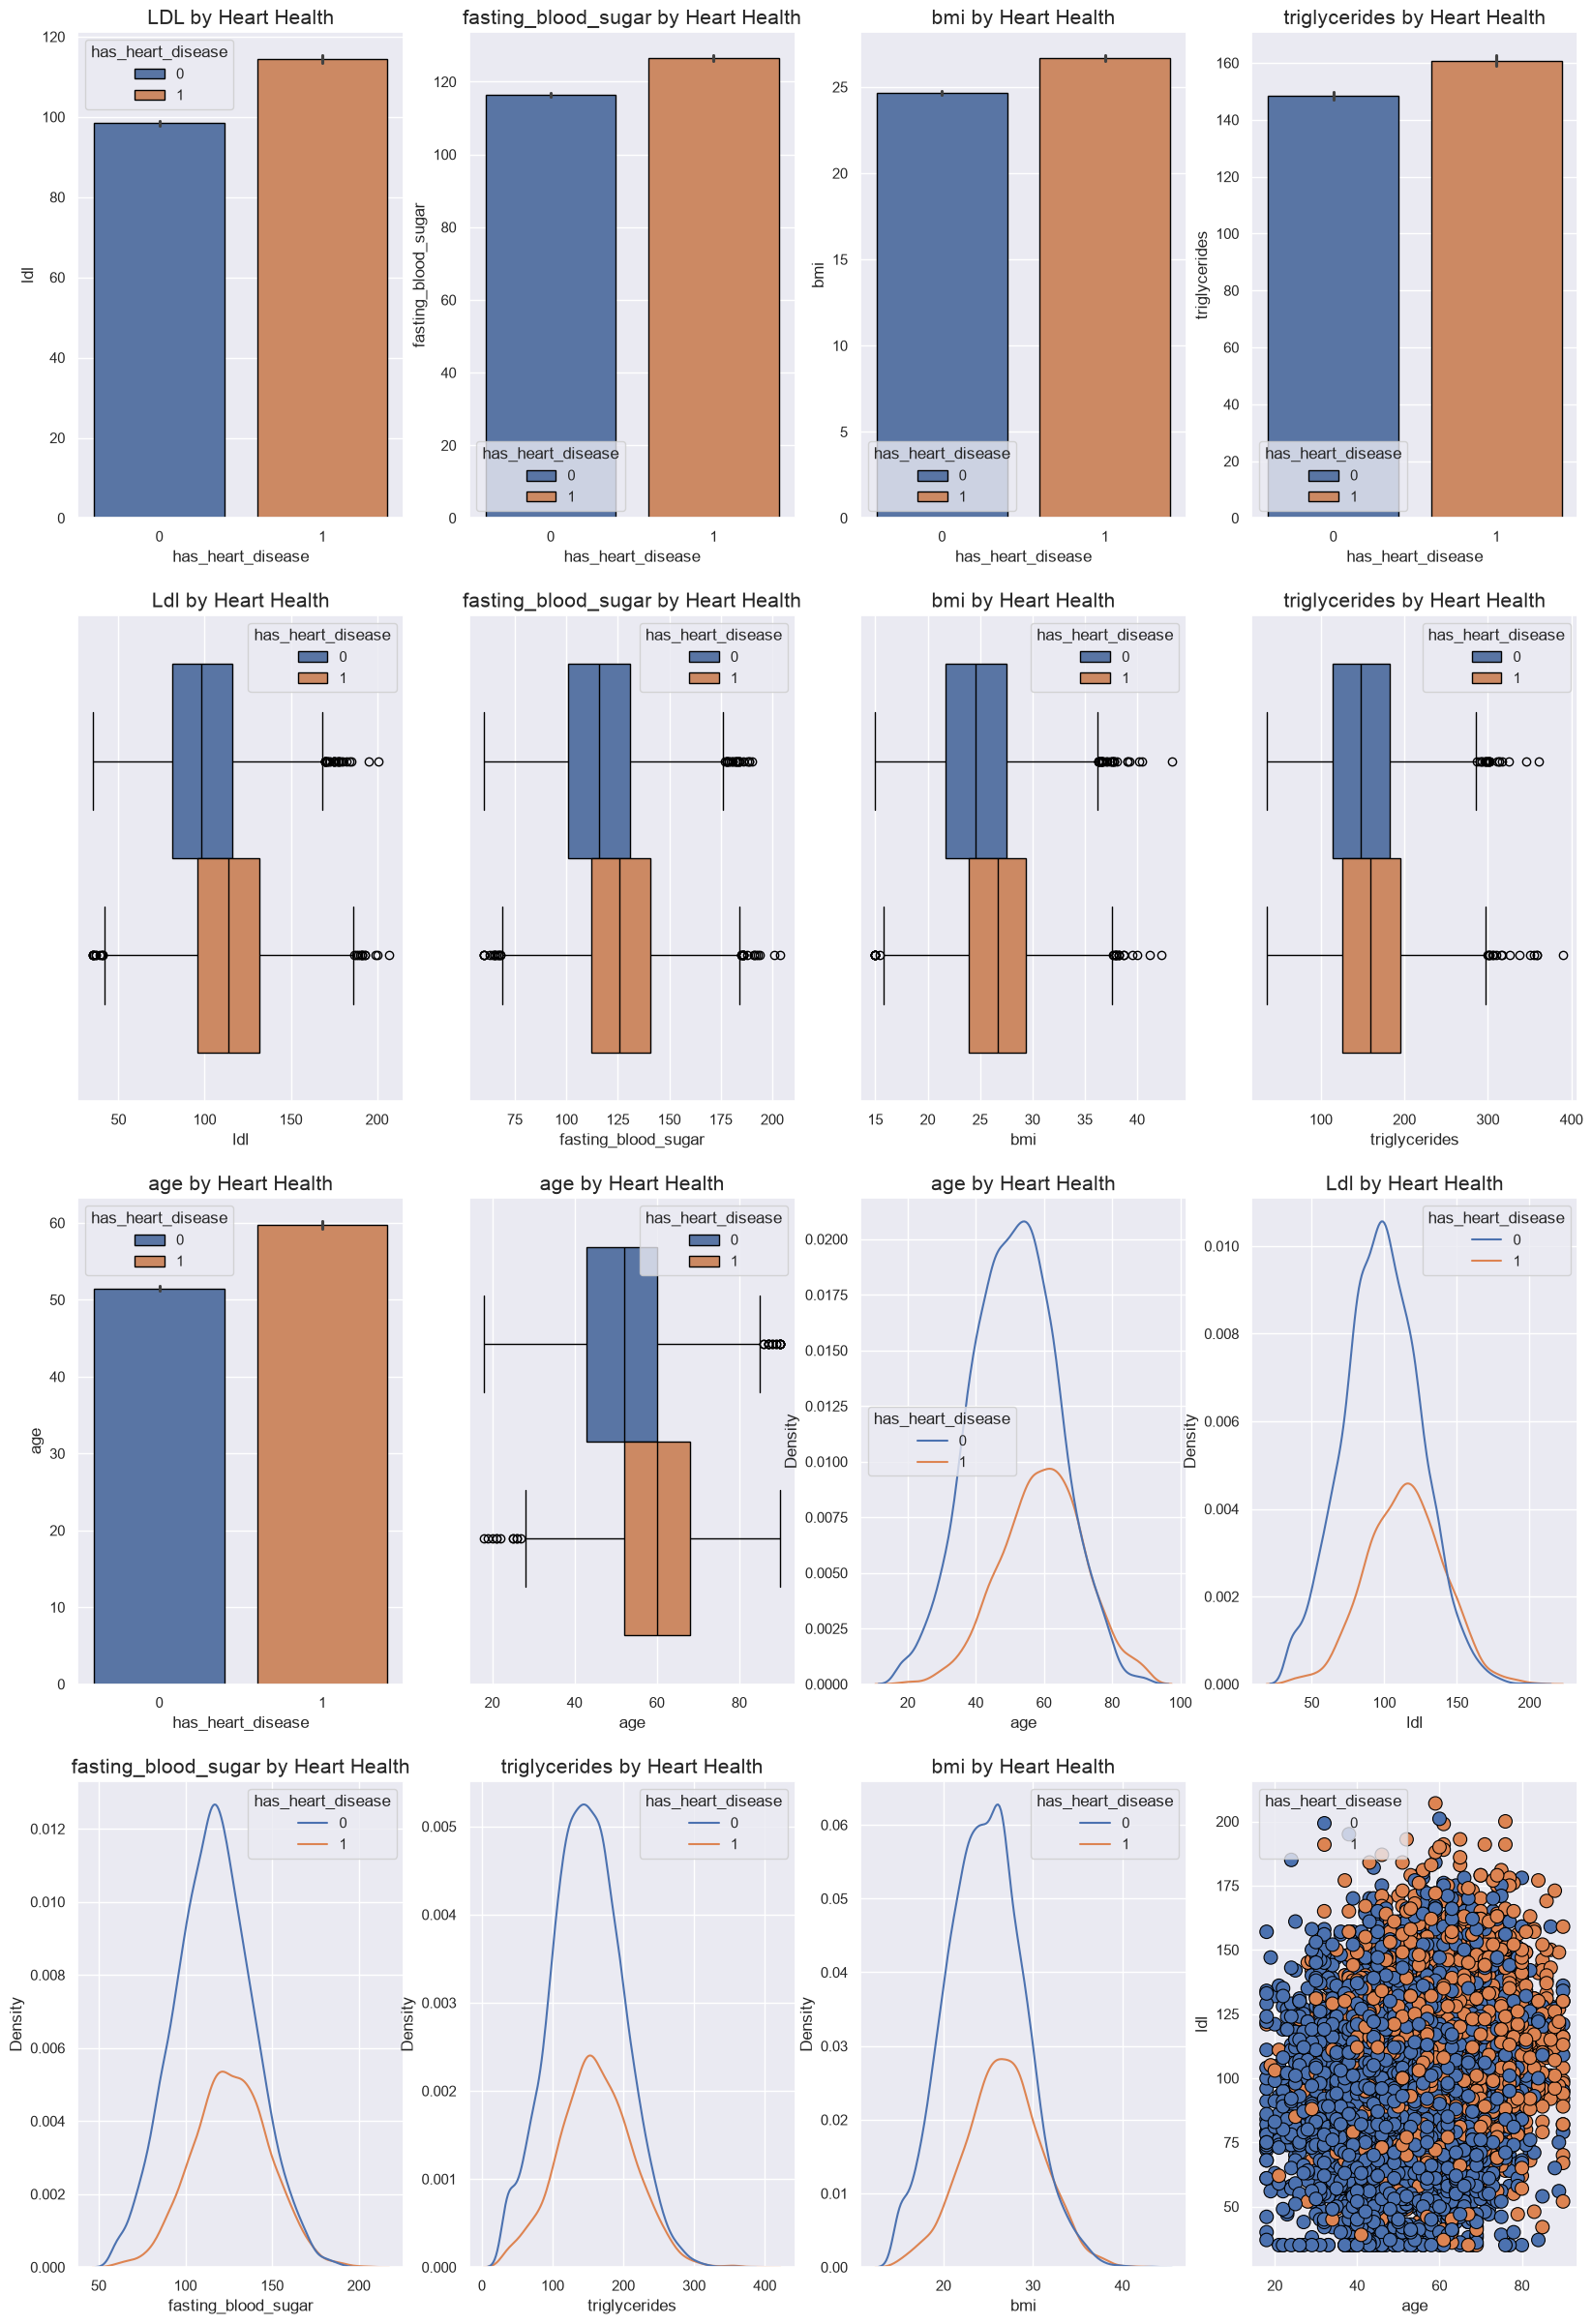

In [60]:
def Subplots_canvas(grid=[2,2],size=(20,12)):
    return plt.subplots(*grid,figsize=size)
def annotater(ax,text,xy,xytext=None,arrowdict={}):
    ax.annotate(text=text,arrow_prop=arrowdict,xy=xy,xytext=xytext)
def CrossTabber(col1,col2='has_heart_disease',col3=None,type:Literal['groupby','crosstab','pivot']='groupby')->pd.DataFrame:
    if type=='groupby':return df.groupby(col2)[col1].agg(['mean'
    ,'median','var','std','max','min']).reset_index()
    elif type=='crosstab':
        return pd.crosstab(index=df[col1],columns=df[col2],normalize='index')*100
    else: return df.pivot_table(index=col1,columns=col2,values=col3,aggfunc='mean')
def Title(fig,text,font={}):
    fig.set_title(text,fontdict=font)
fig,ax=Subplots_canvas(grid=(4,4),size=(20,30))
bar=sns.barplot(data=df,x=TARGET,y='ldl',hue=TARGET,ax=ax[0,0],edgecolor='black');Title(bar,'LDL by Heart Health'
,dict(fontsize=15))
bar2=sns.barplot(data=df,x=TARGET,y='fasting_blood_sugar',hue=TARGET,ax=ax[0,1],edgecolor='black');Title(bar2,'fasting_blood_sugar by Heart Health'
,dict(fontsize=15))
bar3=sns.barplot(data=df,x=TARGET,y='bmi',hue=TARGET,ax=ax[0,2],edgecolor='black');Title(bar3,'bmi by Heart Health'
,dict(fontsize=15))
bar4=sns.barplot(data=df,x=TARGET,y='triglycerides',hue=TARGET,ax=ax[0,3],edgecolor='black');Title(bar4,'triglycerides by Heart Health'
,dict(fontsize=15))
box1=sns.boxplot(data=df,x='ldl',ax=ax[1,0],hue=TARGET,linecolor='black');Title(box1,'Ldl by Heart Health'
,dict(fontsize=15))
box2=sns.boxplot(data=df,x='fasting_blood_sugar',ax=ax[1,1],hue=TARGET,linecolor='black');Title(box2,'fasting_blood_sugar by Heart Health'
,dict(fontsize=15))
box3=sns.boxplot(data=df,x='bmi',hue=TARGET,ax=ax[1,2],linecolor='black');Title(box3,'bmi by Heart Health'
,dict(fontsize=15))
box4=sns.boxplot(data=df,x='triglycerides',hue=TARGET,ax=ax[1,3],linecolor='black');Title(box4,'triglycerides by Heart Health'
,dict(fontsize=15))
bar5=sns.barplot(data=df,x=TARGET,y='age',hue=TARGET,ax=ax[2,0],edgecolor='black');Title(bar5,'age by Heart Health'
,dict(fontsize=15))
box5=sns.boxplot(data=df,x='age',hue=TARGET,ax=ax[2,1],linecolor='black');Title(box5,'age by Heart Health'
,dict(fontsize=15))
kde1=sns.kdeplot(data=df,x='age',hue=TARGET,ax=ax[2,2]);Title(kde1,'age by Heart Health'
,dict(fontsize=15))
kde2=sns.kdeplot(data=df,x='ldl',hue=TARGET,ax=ax[2,3]);Title(kde2,'Ldl by Heart Health'
,dict(fontsize=15))
kde3=sns.kdeplot(data=df,x='fasting_blood_sugar',hue=TARGET,ax=ax[3,0]);Title(kde3,'fasting_blood_sugar by Heart Health'
,dict(fontsize=15))
kde4=sns.kdeplot(data=df,x='triglycerides',hue=TARGET,ax=ax[3,1]);Title(kde4,'triglycerides by Heart Health'
,dict(fontsize=15))
kde5=sns.kdeplot(data=df,x='bmi',hue=TARGET,ax=ax[3,2]);Title(kde5,'bmi by Heart Health'
,dict(fontsize=15))
scatter1=sns.scatterplot(data=df,x='age',y='ldl',hue=TARGET,ax=ax[3,3],s=100,edgecolor='black')

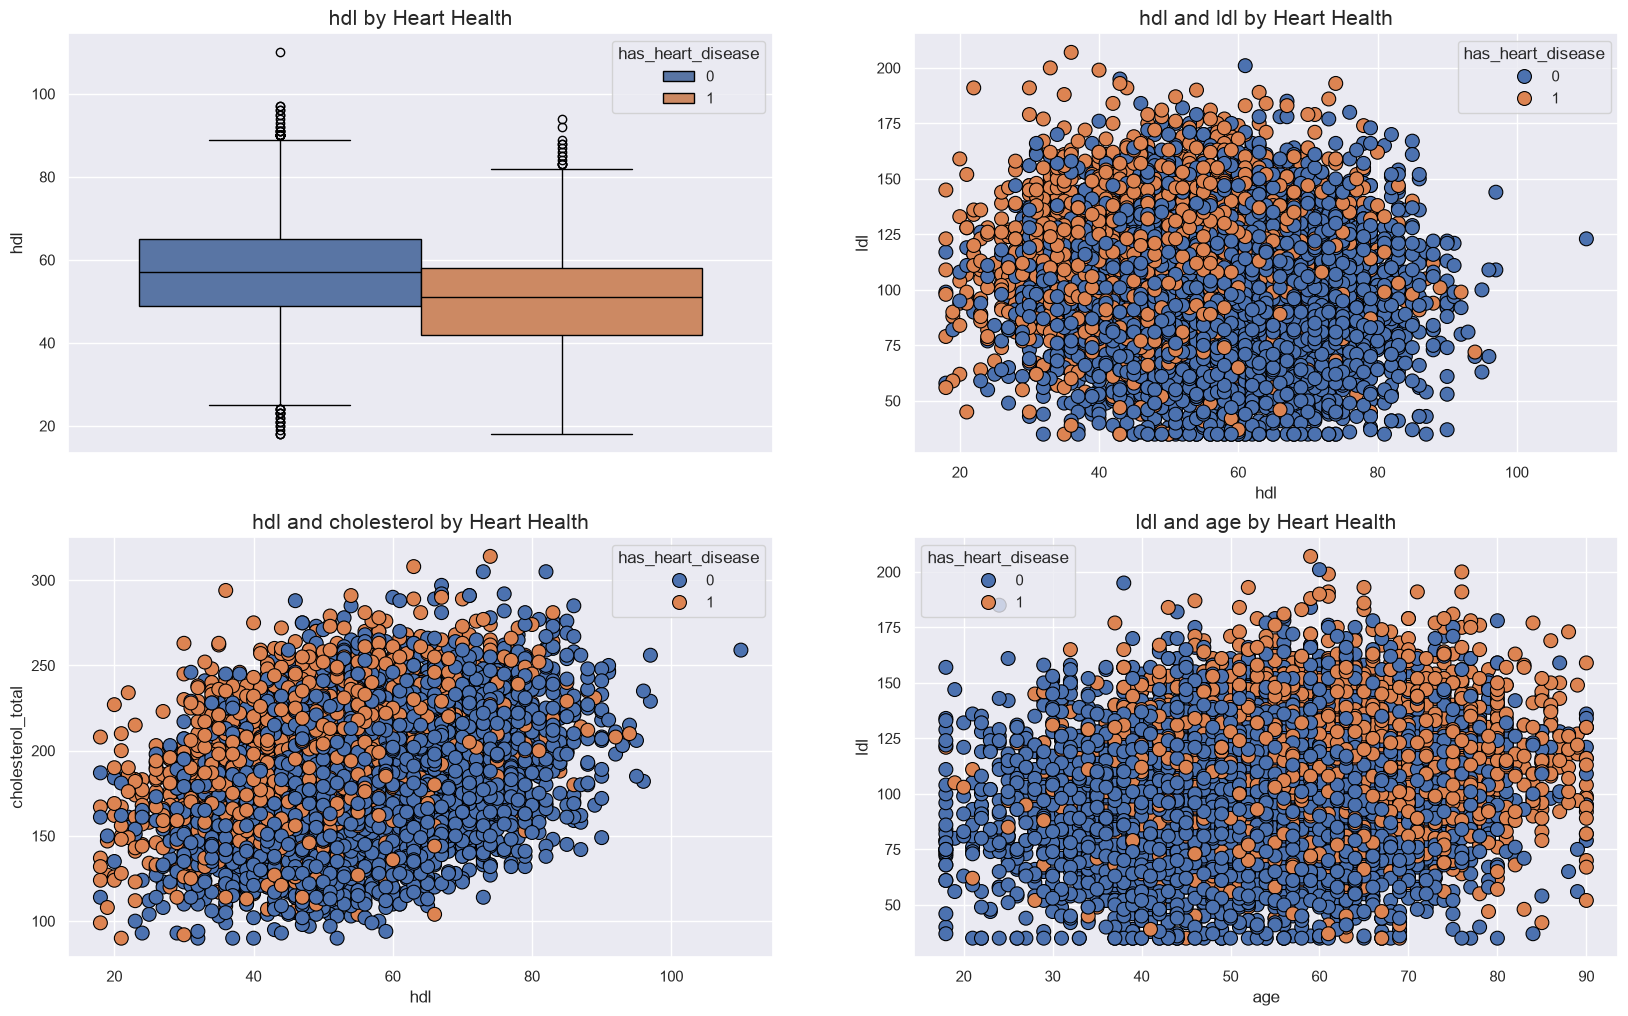

In [61]:
fig,ax=Subplots_canvas()
box6=sns.boxplot(data=df,y='hdl',ax=ax[0,0],hue=TARGET,linecolor='black');Title(box6,'hdl by Heart Health',dict(fontsize=15))
scatter2=sns.scatterplot(data=df,x='hdl',y='ldl',hue=TARGET,ax=ax[0,1],s=100,edgecolor='black');Title(scatter2
,'hdl and ldl by Heart Health',dict(fontsize=15))
scatter3=sns.scatterplot(data=df,x='hdl',y='cholesterol_total',ax=ax[1,0],s=100,edgecolor='black',hue=TARGET);Title(scatter3
,'hdl and cholesterol by Heart Health',dict(fontsize=15))
scatter4=sns.scatterplot(data=df,x='age',y='ldl',ax=ax[1,1],s=100,edgecolor='black',hue=TARGET);Title(scatter4
,'ldl and age by Heart Health',dict(fontsize=15))

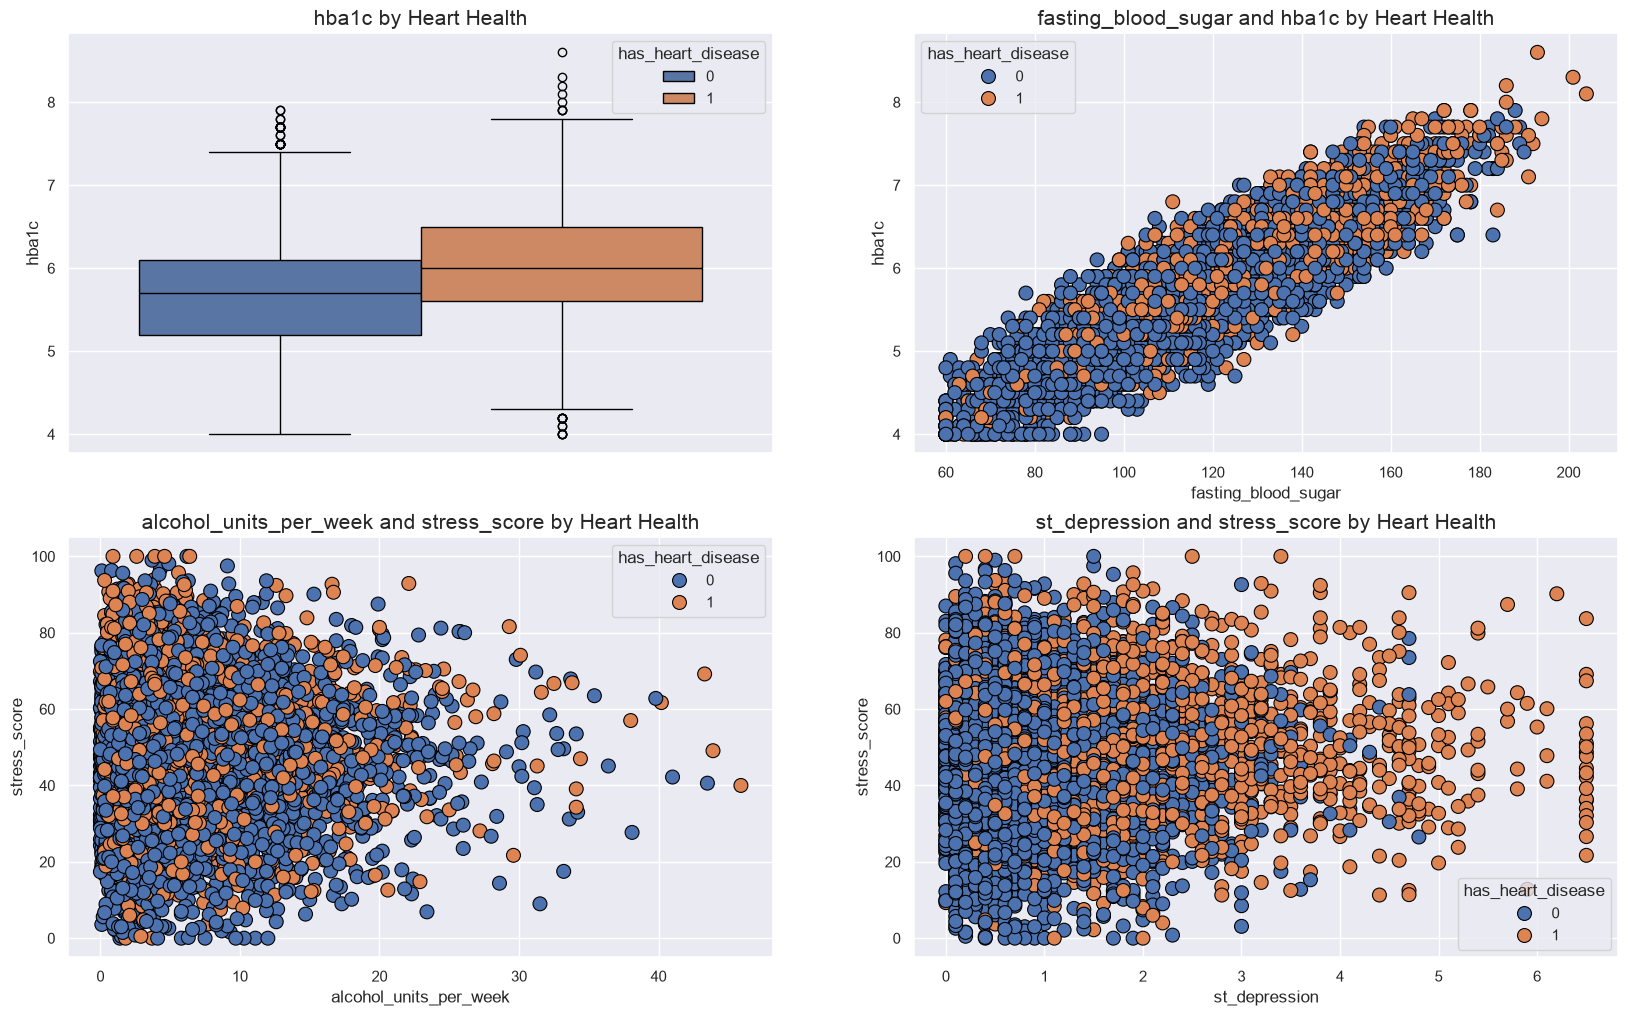

In [62]:
fig,ax=Subplots_canvas()
box6=sns.boxplot(data=df,y='hba1c',ax=ax[0,0],hue=TARGET,linecolor='black');Title(box6,'hba1c by Heart Health',dict(fontsize=15))
scatter2=sns.scatterplot(data=df,x='fasting_blood_sugar',y='hba1c',hue=TARGET,ax=ax[0,1],s=100,edgecolor='black');Title(scatter2
,'fasting_blood_sugar and hba1c by Heart Health',dict(fontsize=15))
scatter3=sns.scatterplot(data=df,x='alcohol_units_per_week',y='stress_score',ax=ax[1,0],s=100,edgecolor='black',hue=TARGET);Title(scatter3
,'alcohol_units_per_week and stress_score by Heart Health',dict(fontsize=15))
scatter4=sns.scatterplot(data=df,x='st_depression',y='stress_score',ax=ax[1,1],s=100,edgecolor='black',hue=TARGET);Title(scatter4
,'st_depression and stress_score by Heart Health',dict(fontsize=15))

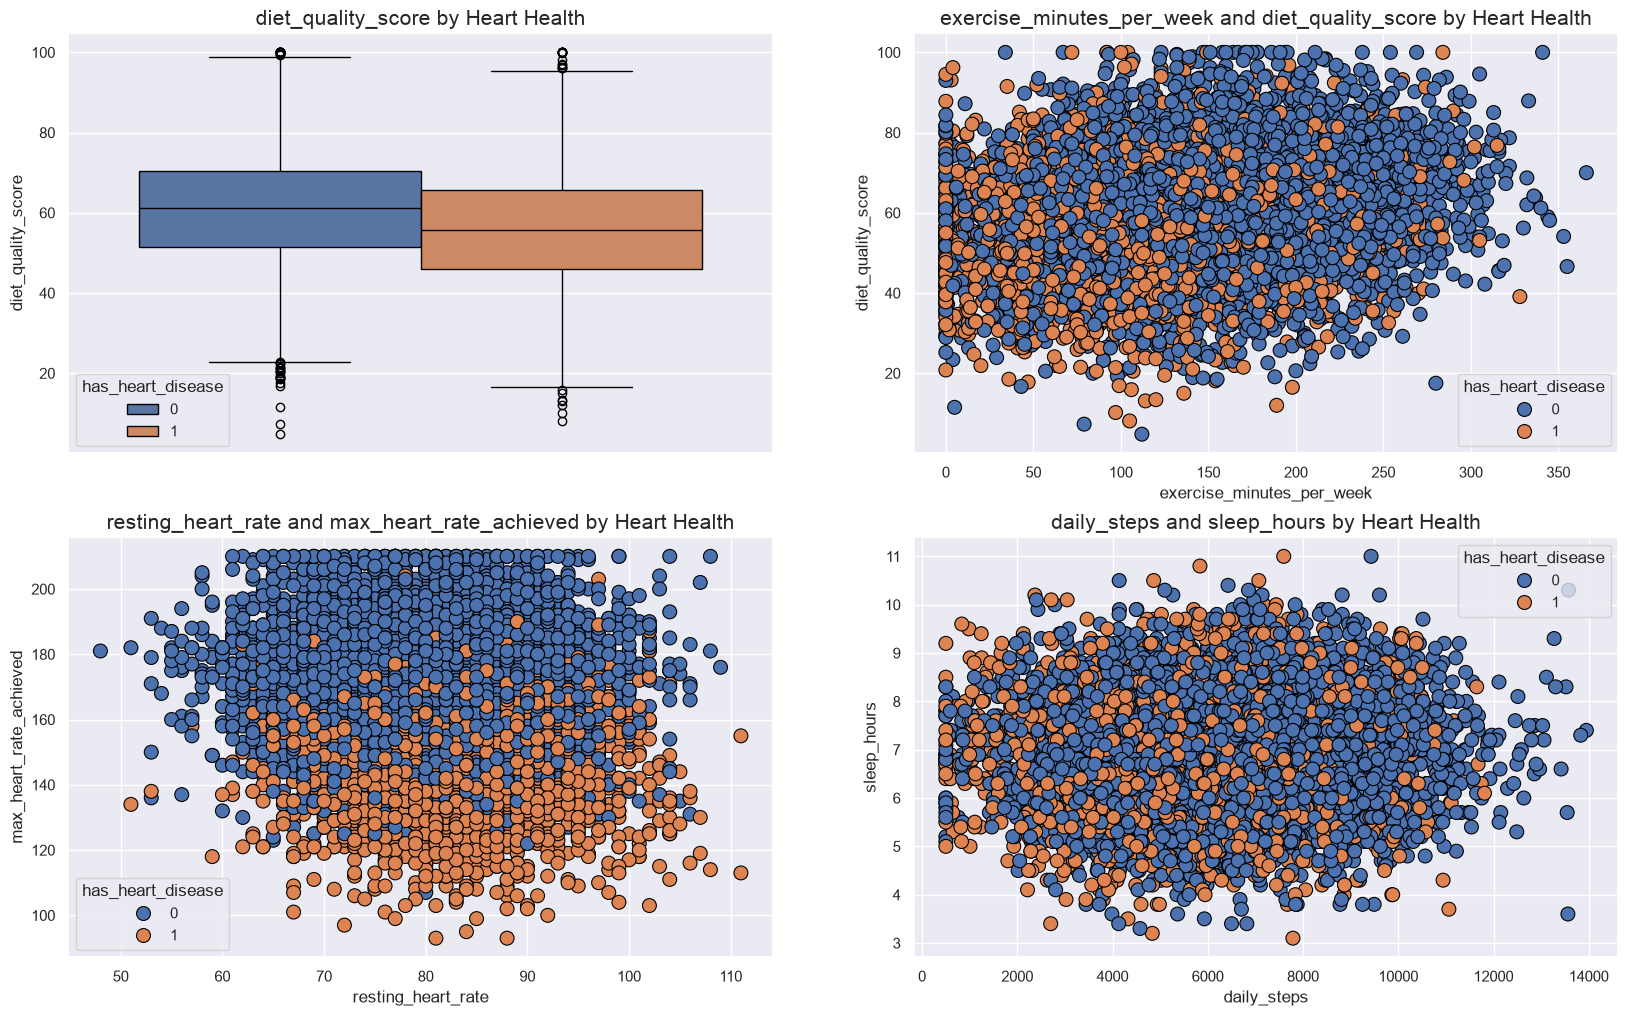

In [63]:
fig,ax=Subplots_canvas()
box6=sns.boxplot(data=df,y='diet_quality_score',ax=ax[0,0],hue=TARGET,linecolor='black');Title(box6,'diet_quality_score by Heart Health',dict(fontsize=15))
scatter2=sns.scatterplot(data=df,x='exercise_minutes_per_week',y='diet_quality_score',hue=TARGET,ax=ax[0,1],s=100,edgecolor='black');Title(scatter2
,'exercise_minutes_per_week and diet_quality_score by Heart Health',dict(fontsize=15))
scatter3=sns.scatterplot(data=df,x='resting_heart_rate',y='max_heart_rate_achieved',ax=ax[1,0],s=100,edgecolor='black',hue=TARGET);Title(scatter3
,'resting_heart_rate and max_heart_rate_achieved by Heart Health',dict(fontsize=15))
scatter4=sns.scatterplot(data=df,x='daily_steps',y='sleep_hours',ax=ax[1,1],s=100,edgecolor='black',hue=TARGET);Title(scatter4
,'daily_steps and sleep_hours by Heart Health',dict(fontsize=15))

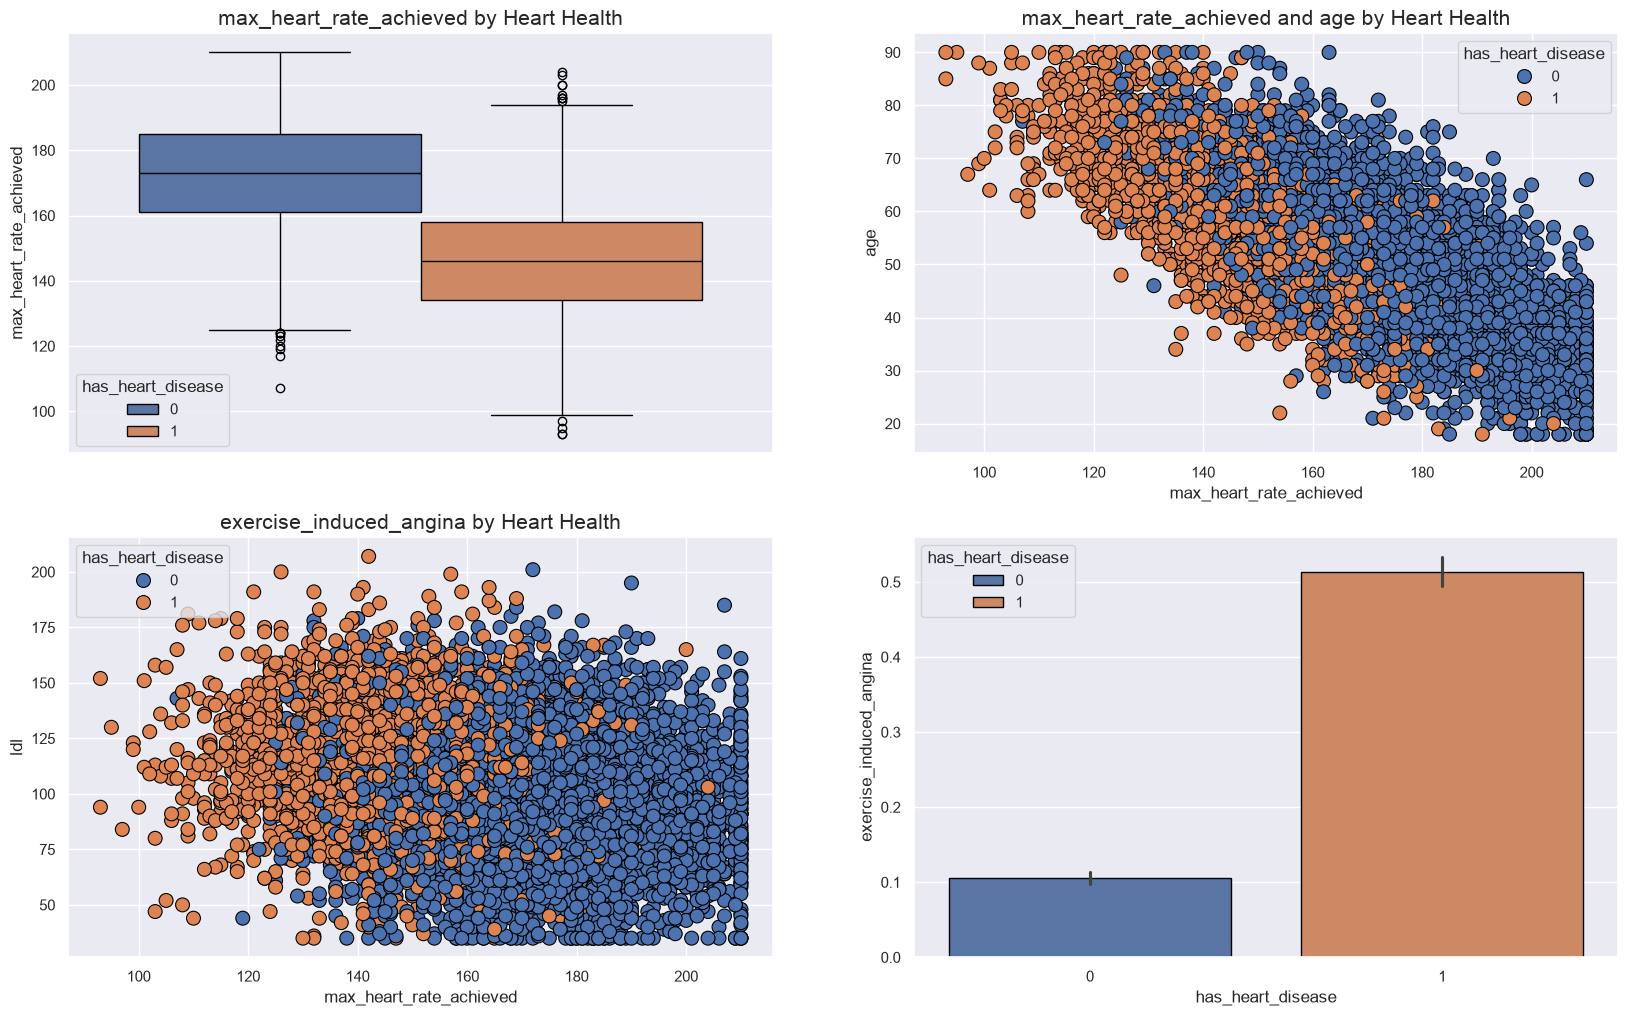

In [64]:
fig,ax=Subplots_canvas()
box6=sns.boxplot(data=df,y='max_heart_rate_achieved',ax=ax[0,0],hue=TARGET,linecolor='black');Title(box6,'max_heart_rate_achieved by Heart Health',dict(fontsize=15))
scatter2=sns.scatterplot(data=df,x='max_heart_rate_achieved',y='age',hue=TARGET,ax=ax[0,1],s=100,edgecolor='black');Title(scatter2
,'max_heart_rate_achieved and age by Heart Health',dict(fontsize=15))
scatter3=sns.scatterplot(data=df,x='max_heart_rate_achieved',y='ldl',ax=ax[1,0],s=100,edgecolor='black',hue=TARGET);Title(scatter3
,'ldl and max_heart_rate_achieved by Heart Health',dict(fontsize=15))
bar6=sns.barplot(data=df,x=TARGET,y='exercise_induced_angina',ax=ax[1,1],edgecolor='black',hue=TARGET);Title(scatter3
,'exercise_induced_angina by Heart Health',dict(fontsize=15))

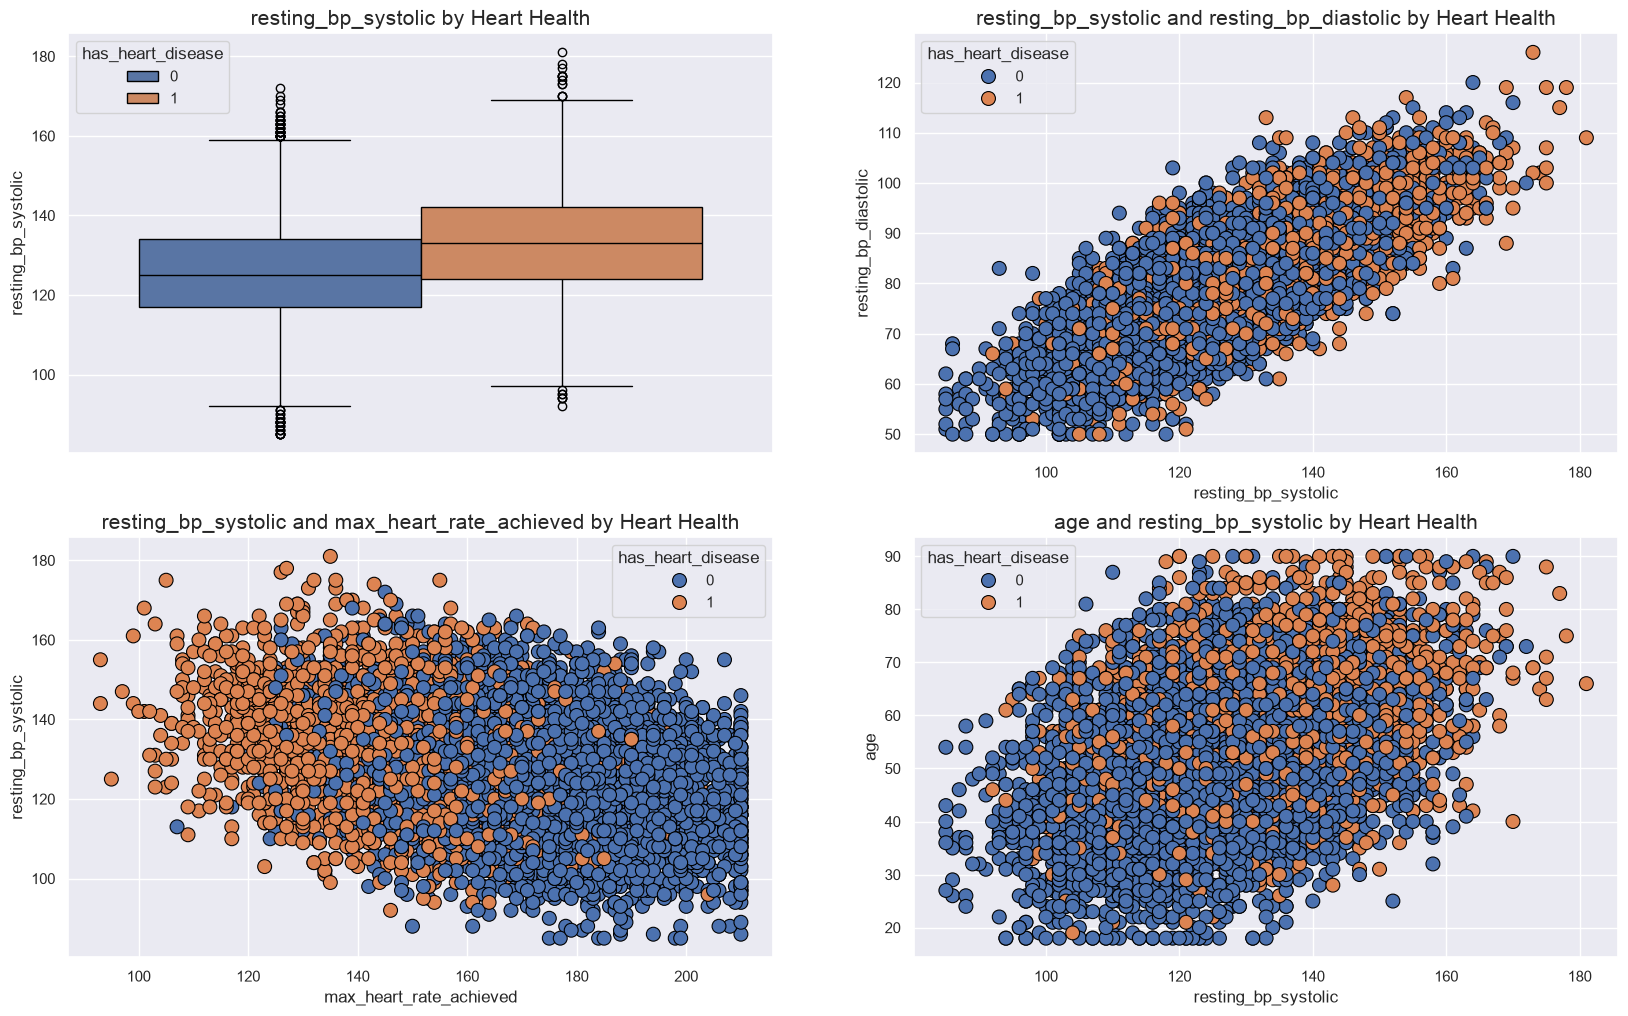

In [65]:
fig,ax=Subplots_canvas()
box6=sns.boxplot(data=df,y='resting_bp_systolic',ax=ax[0,0],hue=TARGET,linecolor='black');Title(box6,'resting_bp_systolic by Heart Health',dict(fontsize=15))
scatter2=sns.scatterplot(data=df,x='resting_bp_systolic',y='resting_bp_diastolic',hue=TARGET,ax=ax[0,1],s=100,edgecolor='black');Title(scatter2
,'resting_bp_systolic and resting_bp_diastolic by Heart Health',dict(fontsize=15))
scatter3=sns.scatterplot(data=df,x='max_heart_rate_achieved',y='resting_bp_systolic',ax=ax[1,0],s=100,edgecolor='black',hue=TARGET);Title(scatter3
,'resting_bp_systolic and max_heart_rate_achieved by Heart Health',dict(fontsize=15))
scatter4=sns.scatterplot(data=df,x='resting_bp_systolic',y='age',ax=ax[1,1],s=100,edgecolor='black',hue=TARGET);Title(scatter4
,'age and resting_bp_systolic by Heart Health',dict(fontsize=15))

**Conclusions**

1) As age increases risk of heart disease increases and so as with ldl , therefore they both together provides better signals.

2) Also high triglycerides and bmi and blood sugar can increase the chances of heart disease.

3) People having heart disease has low hdl levels.

4) More cases are found where hdl levels are low and ldl levels are high.

5) People with high cholesterol have higher chances of heart disease, which means ldl and cholesterol are  high positively Correlated.

6) With increase in age and ldl , cholesterol increases and hdl decreases leading to increased risk of heart disease.

7) Blood_glucose and hba1c levels are higly correlated.

8) Higher Stress score may lead to heart_disease.

9) Higher depression higher the chances of heart_disease.

10) Lower diet score and excercise minutes leads to heart disease.

11) One's having higher max_heart_rate tends to bear less risk of heart disease.

12) Age and max_heart rate are negatively correlated with each other and chance of heart disease lies where age and max heartrates are low.

13) Found most Numerical columns being correlated with each other.

14) With higher induced angina higher the chances of heartrisk which means moderate correlation with the target.

15) Males having more chances of getting diseases as comparison to females.

16) Asymptomatic chest pain type have more chances of heart disease.

**Feature Engineering can help model learn more about the data**

### 3.3 Multivariate

1) Correlation ✅

2) Mutual_Info ✅

3) Multi Collinearity ❌ - The problem exists because some columns like ldl and cholesterol have high correlation leading to difficulty for linear models to differentiate in them, hence we will be using non linear models.

,Features,Correlation_with_heart_risk,Mutual_Info
22,has_heart_disease,1.000000,0.614051
12,exercise_induced_angina,0.445412,0.094926
13,st_depression,0.356817,0.062785
0,age,0.290954,0.038225
5,ldl,0.267150,0.040212
1,resting_bp_systolic,0.249089,0.033149
8,hba1c,0.225830,0.019309
9,bmi,0.213249,0.023571
7,fasting_blood_sugar,0.202358,0.019942
2,resting_bp_diastolic,0.193104,0.016345


,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,st_depression,family_history,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
age,1.000000,0.417806,0.325367,0.127731,-0.044404,0.162302,0.011041,0.143855,0.156264,0.039013,...,0.091256,-0.009774,-0.006700,-0.177415,0.012247,0.034727,-0.014010,-0.179010,-0.029748,0.290954
resting_bp_systolic,0.417806,1.000000,0.767131,0.103243,-0.099598,0.125662,0.088658,0.123649,0.142820,0.267527,...,0.082864,-0.001879,0.080252,-0.208676,-0.012507,0.166701,-0.068382,-0.127868,-0.059250,0.249089
resting_bp_diastolic,0.325367,0.767131,1.000000,0.078116,-0.072862,0.091444,0.074779,0.086416,0.103883,0.204737,...,0.065295,-0.002945,0.067402,-0.163231,-0.028537,0.127810,-0.067608,-0.109219,-0.052303,0.193104
cholesterol_total,0.127731,0.103243,0.078116,1.000000,0.287822,0.841361,0.347647,0.050895,0.060513,0.155636,...,0.054714,0.004472,0.052598,0.027857,-0.011633,-0.023361,0.017032,0.009008,-0.151784,0.167516
hdl,-0.044404,-0.099598,-0.072862,0.287822,1.000000,-0.082460,-0.084219,-0.075956,-0.083552,-0.240855,...,-0.095251,0.008457,-0.025416,0.284646,-0.012647,-0.055353,0.100494,0.112247,0.170579,-0.251505
ldl,0.162302,0.125662,0.091444,0.841361,-0.082460,1.000000,0.069901,0.062252,0.070964,0.181230,...,0.092348,0.011833,-0.017613,-0.075009,-0.006498,-0.001160,-0.024300,-0.029117,-0.191114,0.267150
triglycerides,0.011041,0.088658,0.074779,0.347647,-0.084219,0.069901,1.000000,0.079961,0.091954,0.284031,...,0.040409,-0.014089,0.234464,-0.054478,-0.003284,0.005444,-0.004180,-0.019219,-0.173407,0.110365
fasting_blood_sugar,0.143855,0.123649,0.086416,0.050895,-0.075956,0.062252,0.079961,1.000000,0.877319,0.228646,...,0.085624,-0.011631,-0.003454,-0.168518,-0.006272,0.024338,-0.055280,-0.064678,-0.050234,0.202358
hba1c,0.156264,0.142820,0.103883,0.060513,-0.083552,0.070964,0.091954,0.877319,1.000000,0.251839,...,0.093673,-0.014516,0.004729,-0.191007,-0.005381,0.026944,-0.062126,-0.072347,-0.052664,0.225830
bmi,0.039013,0.267527,0.204737,0.155636,-0.240855,0.181230,0.284031,0.228646,0.251839,1.000000,...,0.072929,-0.011292,-0.014097,-0.192731,-0.013262,0.032952,-0.072421,-0.084183,-0.108692,0.213249


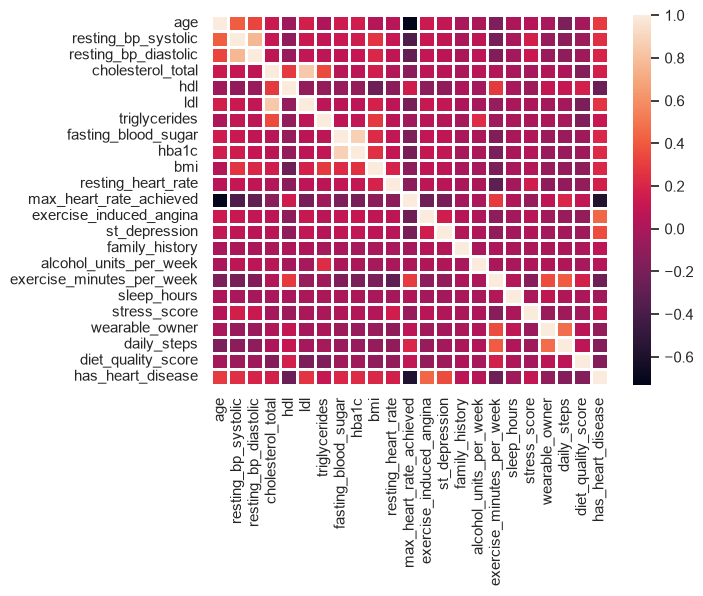

In [66]:
Matrix=df.corr(numeric_only=True)
feature_Corr=pd.DataFrame(dict(
    Features=Matrix.columns,
    Correlation_with_heart_risk=Matrix['has_heart_disease'].values,
    Mutual_Info=mutual_info_classif(df[Matrix.columns],y=df[TARGET])
)).sort_values(by='Correlation_with_heart_risk',ascending=False)
sns.heatmap(data=Matrix,linecolor='white',linewidths=2)
display(feature_Corr,Matrix)

### Data Validation and Checks

In [67]:
print(f'Shape : {df.shape}')
assert df.isnull().sum().all()==0
print(f'Found {df.isnull().sum().sum()} Null Values | Test 1 : Passed')
assert "patient_id" not in df
print(f'~patient_id~ Not Found | Test 2 : Passed')
assert df.select_dtypes(include='number').any().all() > 0
print(f'No Invalid Values Encountered | Test 3 Passed')

Shape : (9000, 26)
Found 0 Null Values | Test 1 : Passed
~patient_id~ Not Found | Test 2 : Passed
No Invalid Values Encountered | Test 3 Passed


So our data is now ready for being processed and served to the model. We will not be using linear Model here.

# 4. Model Training and Evaluation (Initial) (With all Features)

In [68]:
def dtype_converter(cols={},data=df):
    for Column,Dtype in cols.items():
        print()
        data[Column]=data[Column].astype(Dtype)
def Splitter(data=df,test_size=0.2):
    return train_test_split(data.drop(columns=TARGET)
            ,data[TARGET],test_size=test_size,stratify=data[TARGET],random_state=RANDOM_STATE)
def Scorer(Actual,Predicted):
    Canditates=dict(
        Accuracy=accuracy_score(y_pred=Predicted,y_true=Actual),
        Recall=recall_score(y_pred=Predicted,y_true=Actual),
        Precision=precision_score(y_pred=Predicted,y_true=Actual),
        F1=f1_score(y_pred=Predicted,y_true=Actual),
    );return Canditates
def make_pipeline(transformers={},type:Literal["Imb","Skl"]="Skl"):
    steps=[]
    for Name,transformer in transformers.items():
        steps.append((f'{Name}',transformer))
    if type=='Skl': 
        return Pipeline(steps=steps) 
    else: 
        return Ppl(steps=steps)
def make_tranformer():
    Num_pipe=make_pipeline(transformers=dict(
        Scaler=RobustScaler()
    ));Cat_pipe_ohe=make_pipeline(transformers=dict(
        Encoder=OneHotEncoder(sparse_output=False,dtype=int,drop='first')
    ));Cat_pipe_ord=make_pipeline(transformers=dict(
        Ord_Encoder=OrdinalEncoder(categories=[['Asymptomatic','Non-Anginal Pain'
        ,'Atypical Angina','Typical Angina']])
    ))
    return ColumnTransformer(transformers=[('Numerical',Num_pipe,make_column_selector(dtype_include=['int','float']))
        ,('Ohe',Cat_pipe_ohe,make_column_selector(dtype_include=['object','bool'])),
        ('Ord',Cat_pipe_ord,make_column_selector(dtype_include='category'))])
def Trainer(estimator,data=df,type:Literal["Imb","Skl"]="Skl"):
    x_train,x_test,y_train,y_test=Splitter(data=data);rows=[]
    transformer=make_tranformer()
    if type=='Skl':
        final_pipe=make_pipeline(dict(
            transformers=transformer,estimator=clone(estimator)
        ))
    else : 
        final_pipe=make_pipeline(
            transformers=dict(
                transformers=transformer,
                Balancer=SVMSMOTE(k_neighbors=10,random_state=RANDOM_STATE),
                estimator=clone(estimator)
            ),
            type=type
        )
    oof_Scores=cross_validate(estimator=final_pipe,X=x_train,y=y_train
                ,cv=StratifiedKFold(shuffle=True,random_state=RANDOM_STATE),scoring={'accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'},error_score='raise')
    rows.append({
        "Accuracy":oof_Scores['test_accuracy'].mean(),
        "Recall":oof_Scores['test_recall'].mean(),
        "Precision":oof_Scores['test_precision'].mean(),
        "F1":oof_Scores['test_f1'].mean(),
    })
    return pd.DataFrame(rows).mean()
OverSamping_Candidates={
    'Dummy':DummyClassifier(),
    'DecisionTree':DecisionTreeClassifier(max_depth=6,random_state=RANDOM_STATE,splitter='random'),
    'RandomForest':RandomForestClassifier(max_depth=5,n_estimators=1000,n_jobs=-1,random_state=RANDOM_STATE,bootstrap=True,max_samples=0.25),
    'ExtraTrees':ExtraTreeClassifier(max_depth=7,random_state=RANDOM_STATE,splitter='random'),
    'HistGradientBoost':HistGradientBoostingClassifier(learning_rate=0.1,random_state=RANDOM_STATE,max_depth=3),
    'XgBoost':xgb.XGBClassifier(max_depth=3,random_state=RANDOM_STATE,learning_rate=0.1,tree_method='hist')
};Class_weight_candidates={
    'Dummy':DummyClassifier(),
    'DecisionTree':DecisionTreeClassifier(max_depth=6,random_state=RANDOM_STATE,splitter='random',class_weight={0:1,1:5}),
    'RandomForest':RandomForestClassifier(max_depth=5,n_estimators=1000,n_jobs=-1,random_state=RANDOM_STATE,bootstrap=True,max_samples=0.25,class_weight={0:1,1:5}),
    'ExtraTrees':ExtraTreeClassifier(max_depth=7,random_state=RANDOM_STATE,splitter='random',class_weight={0:1,1:5}),
    'HistGradientBoost':HistGradientBoostingClassifier(learning_rate=0.1,random_state=RANDOM_STATE,max_depth=3,class_weight={0:1,1:5}),
    'XgBoost':xgb.XGBClassifier(max_depth=3,random_state=RANDOM_STATE,learning_rate=0.1,tree_method='hist',scale_pos_weight=5)
};dtype_converter(cols=dict(chest_pain_type="category"));Class_weight_results=[];OverSamping_Results=[]
for Name,Model in OverSamping_Candidates.items():
    Score=Trainer(estimator=Model,type='Imb')
    OverSamping_Results.append([Name,Score.Accuracy,Score.Recall,Score.Precision,Score.F1])
for Name,Model in Class_weight_candidates.items():
    Score=Trainer(estimator=Model)
    Class_weight_results.append([Name,Score.Accuracy,Score.Recall,Score.Precision,Score.F1])
OverSamping_Results_Table=pd.DataFrame(OverSamping_Results,columns=['Model','Accuracy','Recall','Precision','F1']).sort_values('F1',ascending=False)
Class_weight_results_Table=pd.DataFrame(Class_weight_results,columns=['Model','Accuracy','Recall','Precision','F1']).sort_values('F1',ascending=False)
display(OverSamping_Results_Table.style.format({'Accuracy':'{:.4f}','Recall':'{:.2f}','Precision':'{:.2f}','F1':'{:.2f}'}))
display(Class_weight_results_Table.style.format({'Accuracy':'{:.4f}','Recall':'{:.2f}','Precision':'{:.2f}','F1':'{:.2f}'}))

,Model,Accuracy,Recall,Precision,F1
5,XgBoost,0.8660,0.87,0.74,0.80
4,HistGradientBoost,0.8635,0.86,0.73,0.79
2,RandomForest,0.8283,0.88,0.66,0.76
1,DecisionTree,0.8006,0.83,0.63,0.72
3,ExtraTrees,0.6961,0.77,0.51,0.61
0,Dummy,0.6969,0.00,0.00,0.00


,Model,Accuracy,Recall,Precision,F1
5,XgBoost,0.8392,0.92,0.67,0.78
4,HistGradientBoost,0.8374,0.92,0.67,0.77
2,RandomForest,0.7540,0.95,0.56,0.70
1,DecisionTree,0.7669,0.90,0.57,0.70
3,ExtraTrees,0.6210,0.86,0.44,0.58
0,Dummy,0.6969,0.00,0.00,0.00


**Conclusion**

Since Xgboost is performing better among all of them, we will be selecting it.

# 5. Hyperparameter Tuning (Optuna)

In [71]:
# 5. Hyperparameter tuning on the training partition only
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, recall_score, accuracy_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import chi2_contingency

x_train, x_test, y_train, y_test = Splitter(data=df)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
base_estimator = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
    random_state=RANDOM_STATE, tree_method='hist', n_jobs=-1)
tuning_pipe = Ppl(steps=[('Transformer', make_tranformer()),
    ('OverSampler', SVMSMOTE(k_neighbors=10, random_state=RANDOM_STATE)),
    ('estimator', base_estimator)])
search = GridSearchCV(tuning_pipe, {
    'estimator__max_depth':[3,5], 'estimator__n_estimators':[250,450],
    'estimator__learning_rate':[0.05,0.10]}, scoring='average_precision',
    cv=cv, n_jobs=-1, refit=True)
search.fit(x_train, y_train)
best_params = search.best_params_
print('Best cross-validated PR-AUC:', round(search.best_score_, 4))
print('Best parameters:', best_params)


Best cross-validated PR-AUC: 0.8913
Best parameters: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 250}


# 6. Initial Evaluation (Test Remains Untouched)

In [72]:
# 6. Tuned baseline evaluation with out-of-fold probabilities
def tuned_xgb():
    params = {k.replace('estimator__',''):v for k,v in best_params.items()}
    return xgb.XGBClassifier(**params, objective='binary:logistic', eval_metric='logloss',
                             random_state=RANDOM_STATE, tree_method='hist', n_jobs=-1)
baseline_model = Ppl(steps=[('Transformer', make_tranformer()),
    ('OverSampler', SVMSMOTE(k_neighbors=10, random_state=RANDOM_STATE)),
    ('estimator', tuned_xgb())])
oof_baseline_proba = cross_val_predict(baseline_model, x_train, y_train, cv=cv,
                                       method='predict_proba', n_jobs=-1)[:, 1]
oof_baseline_pred = (oof_baseline_proba >= 0.50).astype(int)


# 7. Error Analysis

In [73]:
# 7. Statistical feature selection, feature construction, and threshold tuning
class FeatureConstructor(BaseEstimator, TransformerMixin):
    """Leakage-safe, row-wise domain features fitted inside each CV fold."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        z = X.copy()
        z['age_x_ldl'] = z['age'] * z['ldl']
        z['bp_ratio'] = z['resting_bp_systolic'] / (z['resting_bp_diastolic'] + 1)
        z['cholesterol_ratio'] = z['cholesterol_total'] / (z['hdl'] + 1)
        z['bmi_x_activity'] = z['bmi'] * z['exercise_minutes_per_week']
        z['metabolic_risk_score'] = z['hba1c'] + z['triglycerides'] / 100
        z['lipid_gap'] = z['ldl'] - z['hdl']
        z['pain_x_history'] = z['chest_pain_type'].astype(str) + '_' + z['family_history'].astype(str)
        return z

num_cols = x_train.select_dtypes(include=np.number).columns
f_values, f_pvalues = f_classif(x_train[num_cols], y_train)
anova_table = pd.DataFrame({'Feature':num_cols, 'ANOVA_F':f_values, 'p_value':f_pvalues}).sort_values('p_value')
mi_values = mutual_info_classif(x_train[num_cols], y_train, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({'Feature':num_cols, 'Mutual_Information':mi_values}).sort_values('Mutual_Information', ascending=False)
chi_rows = []
for col in x_train.select_dtypes(exclude=np.number).columns:
    stat, p_value, _, _ = chi2_contingency(pd.crosstab(x_train[col], y_train))
    chi_rows.append({'Feature':col, 'Chi2':stat, 'p_value':p_value})
chi_table = pd.DataFrame(chi_rows).sort_values('p_value')
display(anova_table.head(15)); display(mi_table.head(15)); display(chi_table)

engineered_transformer = Pipeline([('construction', FeatureConstructor()), ('preprocessing', make_tranformer())])
selected_model = Ppl(steps=[('construction', FeatureConstructor()),
    ('preprocessing', make_tranformer()),
    ('selection', SelectKBest(score_func=mutual_info_classif, k='all')),
    ('OverSampler', SVMSMOTE(k_neighbors=10, random_state=RANDOM_STATE)),
    ('estimator', tuned_xgb())])
probe = engineered_transformer.fit_transform(x_train, y_train)
feature_count = probe.shape[1]
k_grid = sorted(set([max(8, int(feature_count*.40)), max(8, int(feature_count*.60)),
                     max(8, int(feature_count*.80))]))
selection_rows = []
for k in k_grid:
    candidate = clone(selected_model).set_params(selection__k=k)
    scores = cross_validate(candidate, x_train, y_train, cv=cv,
        scoring={'accuracy':'accuracy','f1':'f1','recall':'recall','prauc':'average_precision'}, n_jobs=-1)
    selection_rows.append({'Selected_Features':k, 'Accuracy':scores['test_accuracy'].mean(),
                           'F1':scores['test_f1'].mean(), 'Recall':scores['test_recall'].mean(),
                           'PR_AUC':scores['test_prauc'].mean()})
selection_results = pd.DataFrame(selection_rows).sort_values(['PR_AUC','F1'], ascending=False)
best_k = int(selection_results.iloc[0]['Selected_Features'])
selected_model.set_params(selection__k=best_k)
display(selection_results.style.format('{:.4f}'))
print('Selected feature count:', best_k, 'of', feature_count)

oof_selected_proba = cross_val_predict(selected_model, x_train, y_train, cv=cv,
                                       method='predict_proba', n_jobs=-1)[:,1]
def metric_summary(y_true, probabilities, threshold=.50):
    pred = (probabilities >= threshold).astype(int)
    return {'Accuracy':accuracy_score(y_true,pred), 'F1':f1_score(y_true,pred),
            'Recall':recall_score(y_true,pred), 'PR_AUC':average_precision_score(y_true,probabilities)}
before_after = pd.DataFrame([
    {'Model':'Tuned baseline — all original features', **metric_summary(y_train,oof_baseline_proba)},
    {'Model':'Tuned model — constructed + statistically selected features', **metric_summary(y_train,oof_selected_proba)}
]).set_index('Model')
print('Before vs. after feature construction and selection (OOF, threshold = 0.50)')
display(before_after.style.format('{:.4f}'))

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    pred = (oof_selected_proba >= threshold).astype(int)
    threshold_rows.append({'Threshold':threshold, 'Accuracy':accuracy_score(y_train,pred),
                           'F1':f1_score(y_train,pred), 'Recall':recall_score(y_train,pred),
                           'PR_AUC':average_precision_score(y_train,oof_selected_proba)})
threshold_results = pd.DataFrame(threshold_rows)
best_threshold = float(threshold_results.sort_values(['F1','Recall','Accuracy'], ascending=False).iloc[0]['Threshold'])
print('Best threshold selected from training OOF predictions:', round(best_threshold, 2))
display(threshold_results.sort_values(['F1','Recall'], ascending=False).head(10).style.format('{:.4f}'))


,Feature,ANOVA_F,p_value
11,max_heart_rate_achieved,3608.369967,0.000000e+00
12,st_depression,1081.549460,4.113282e-221
0,age,649.977279,2.431691e-137
5,ldl,550.752175,2.027439e-117
4,hdl,469.664391,6.050286e-101
14,exercise_minutes_per_week,461.811826,2.436332e-99
1,resting_bp_systolic,461.452081,2.886054e-99
8,hba1c,396.484682,6.388042e-86
9,bmi,331.113057,2.263700e-72
7,fasting_blood_sugar,316.215877,2.884076e-69


,Feature,Mutual_Information
11,max_heart_rate_achieved,0.193378
12,st_depression,0.069282
0,age,0.052799
14,exercise_minutes_per_week,0.035582
4,hdl,0.035427
8,hba1c,0.033355
5,ldl,0.031888
1,resting_bp_systolic,0.029372
2,resting_bp_diastolic,0.025359
9,bmi,0.020182


,Feature,Chi2,p_value
2,exercise_induced_angina,1398.914687,3.616346e-306
4,smoker_status,197.000488,1.666816e-43
1,chest_pain_type,175.665092,7.612797e-38
0,sex,98.168126,3.843266e-23
5,wearable_owner,52.405862,4.513745e-13
3,family_history,36.168915,1.809338e-09


,Selected_Features,Accuracy,F1,Recall,PR_AUC
3,39.0000,0.8710,0.8015,0.8593,0.8945
2,31.0000,0.8714,0.8028,0.8639,0.8923
1,23.0000,0.8650,0.7956,0.8671,0.8886
0,15.0000,0.8583,0.7876,0.8666,0.8821


Selected feature count: 39 of 39
Before vs. after feature construction and selection (OOF, threshold = 0.50)


,Accuracy,F1,Recall,PR_AUC
Model,,,,
Tuned baseline — all original features,0.8708,0.8004,0.8547,0.8913
Tuned model — constructed + statistically selected features,0.8710,0.8015,0.8593,0.8947


Best threshold selected from training OOF predictions: 0.59


,Threshold,Accuracy,F1,Recall,PR_AUC
49,0.5900,0.8819,0.8079,0.8190,0.8947
50,0.6000,0.8826,0.8078,0.8139,0.8947
52,0.6200,0.8842,0.8076,0.8020,0.8947
46,0.5600,0.8794,0.8074,0.8336,0.8947
47,0.5700,0.8799,0.8070,0.8286,0.8947
45,0.5500,0.8785,0.8069,0.8378,0.8947
51,0.6100,0.8829,0.8069,0.8071,0.8947
48,0.5800,0.8804,0.8067,0.8236,0.8947
44,0.5400,0.8775,0.8066,0.8428,0.8947
53,0.6300,0.8843,0.8065,0.7956,0.8947


# 8. Final Evaluation on the Untouched Test Set

The threshold was selected only from training out-of-fold probabilities. The test partition remains untouched until this final evaluation.


,Accuracy,F1,Recall,PR_AUC
Final test set,0.8928,0.8250,0.8349,0.9112


               precision    recall  f1-score   support

   No disease       0.93      0.92      0.92      1255
Heart disease       0.82      0.83      0.83       545

     accuracy                           0.89      1800
    macro avg       0.87      0.88      0.87      1800
 weighted avg       0.89      0.89      0.89      1800



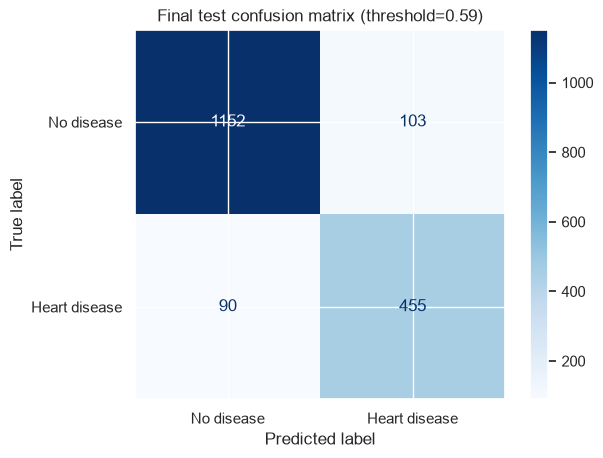

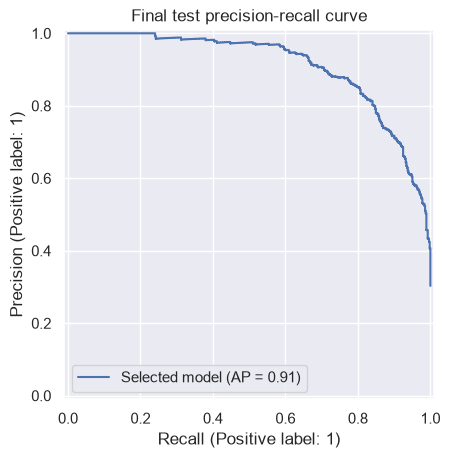

In [74]:
# Refit the selected model on all training rows and evaluate once on the holdout set.
selected_model.fit(x_train, y_train)
test_proba = selected_model.predict_proba(x_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)
test_metrics = pd.DataFrame([{
    'Accuracy':accuracy_score(y_test,test_pred), 'F1':f1_score(y_test,test_pred),
    'Recall':recall_score(y_test,test_pred), 'PR_AUC':average_precision_score(y_test,test_proba)
}], index=['Final test set'])
display(test_metrics.style.format('{:.4f}'))
print(classification_report(y_test, test_pred, target_names=['No disease','Heart disease']))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred,
    display_labels=['No disease','Heart disease'], cmap='Blues')
plt.title(f'Final test confusion matrix (threshold={best_threshold:.2f})'); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, test_proba, name='Selected model')
plt.title('Final test precision-recall curve'); plt.show()


# 9. SHAP Explainability and Business Feature Interpretation

SHAP explains how each selected feature moves a prediction relative to the model baseline. Positive SHAP values increase predicted heart-disease risk; negative values decrease it. The explanations are model explanations, not medical diagnoses.


,Feature,Mean_Abs_SHAP,Mean_SHAP_Direction,Risk_Interpretation,Business_Use
11,Numerical__max_heart_rate_achieved,1.6091,-0.5325,"On average, pushes predictions toward lower risk",Exercise/cardiac response: unusual exercise-heart-rate patterns can change risk priority.
12,Numerical__st_depression,0.5617,-0.0908,"On average, pushes predictions toward lower risk",Stress-test signal: higher ST depression may indicate a need for clinical review.
26,Ohe__exercise_induced_angina_True,0.4956,0.0177,"On average, pushes predictions toward higher risk",Exercise-induced symptoms: important for escalation and diagnostic follow-up.
38,Ord__chest_pain_type,0.3079,-0.0950,"On average, pushes predictions toward lower risk",Chest-pain pattern: supports triage priority and clinician review.
29,Ohe__smoker_status_Never,0.2977,-0.0632,"On average, pushes predictions toward lower risk",Smoking status: supports cessation programs and high-risk outreach.
21,Numerical__cholesterol_ratio,0.2966,-0.0501,"On average, pushes predictions toward lower risk",Cholesterol balance: helps identify patients needing a complete lipid review.
0,Numerical__age,0.2955,0.0490,"On average, pushes predictions toward higher risk",Age-related risk: supports age-banded screening and prevention outreach.
8,Numerical__hba1c,0.2404,-0.0585,"On average, pushes predictions toward lower risk",Long-term glucose control: supports diabetes-risk counselling and screening.
28,Ohe__smoker_status_Former,0.1559,0.0310,"On average, pushes predictions toward higher risk",Smoking status: supports cessation programs and high-risk outreach.
24,Numerical__lipid_gap,0.1517,-0.0459,"On average, pushes predictions toward lower risk",LDL-HDL gap: summarizes an unfavorable lipid profile for preventive targeting.


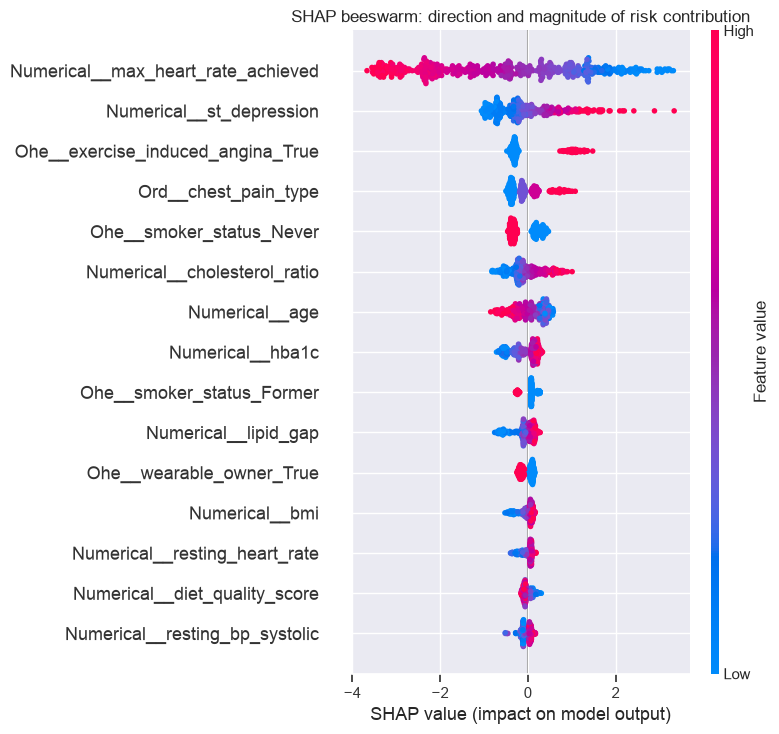

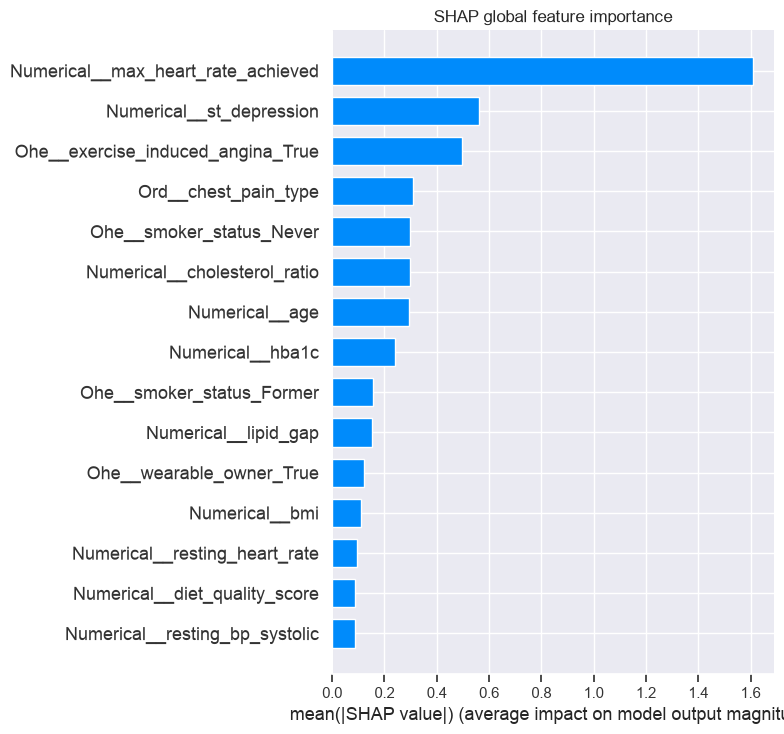

Example patient index: 5129 | predicted probability: 0.9974 | decision: Heart disease risk flag


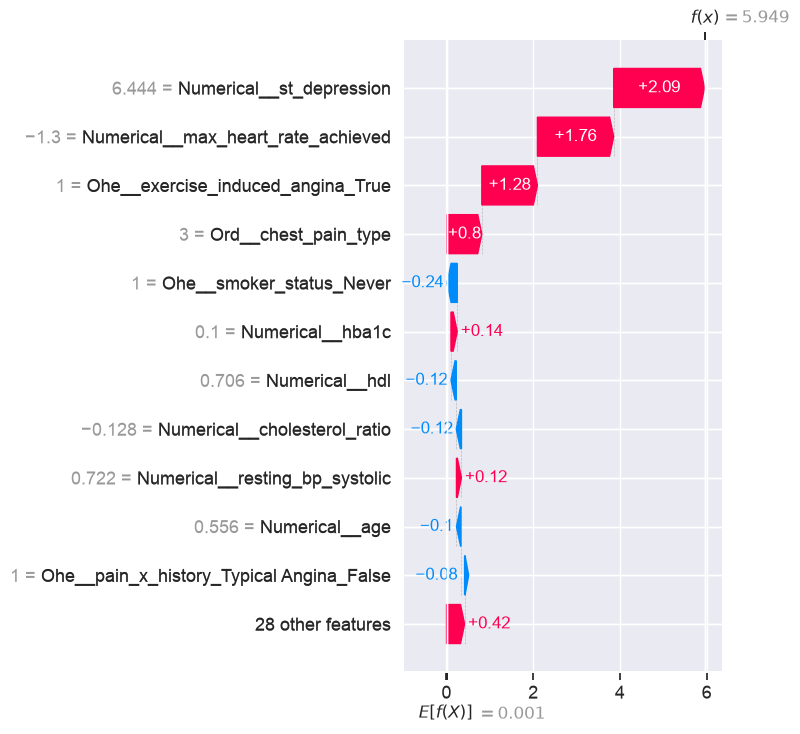

In [75]:
# Global and local SHAP explanations for the final selected XGBoost model
import shap
from IPython.display import display

construction = selected_model.named_steps['construction']
preprocessor = selected_model.named_steps['preprocessing']
selector = selected_model.named_steps['selection']
tree_model = selected_model.named_steps['estimator']

X_test_constructed = construction.transform(x_test)
X_test_prepared = preprocessor.transform(X_test_constructed)
X_test_selected = selector.transform(X_test_prepared)
all_feature_names = preprocessor.get_feature_names_out()
selected_feature_names = all_feature_names[selector.get_support()]
X_shap = X_test_selected.iloc[:min(500, len(X_test_selected))].copy()

explainer = shap.TreeExplainer(tree_model)
raw_shap = explainer.shap_values(X_shap)
if isinstance(raw_shap, list): raw_shap = raw_shap[1]
raw_shap = np.asarray(raw_shap)
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)): expected_value = np.asarray(expected_value).reshape(-1)[-1]

shap_importance = pd.DataFrame({
    'Feature': selected_feature_names,
    'Mean_Abs_SHAP': np.abs(raw_shap).mean(axis=0),
    'Mean_SHAP_Direction': raw_shap.mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

def business_meaning(feature):
    f = feature.lower()
    meanings = [
        ('max_heart_rate_achieved', 'Exercise/cardiac response: unusual exercise-heart-rate patterns can change risk priority.'),
        ('st_depression', 'Stress-test signal: higher ST depression may indicate a need for clinical review.'),
        ('age', 'Age-related risk: supports age-banded screening and prevention outreach.'),
        ('ldl', 'LDL cholesterol: supports lipid-management and follow-up prioritization.'),
        ('hdl', 'HDL cholesterol: supports cardiovascular lifestyle and lipid counselling.'),
        ('cholesterol_ratio', 'Cholesterol balance: helps identify patients needing a complete lipid review.'),
        ('lipid_gap', 'LDL-HDL gap: summarizes an unfavorable lipid profile for preventive targeting.'),
        ('resting_bp_systolic', 'Systolic blood pressure: supports hypertension monitoring and follow-up.'),
        ('resting_bp_diastolic', 'Diastolic blood pressure: adds blood-pressure risk context.'),
        ('bp_ratio', 'Blood-pressure ratio: summarizes the relationship between systolic and diastolic pressure.'),
        ('hba1c', 'Long-term glucose control: supports diabetes-risk counselling and screening.'),
        ('fasting_blood_sugar', 'Fasting glucose: supports metabolic-risk checks and preventive intervention.'),
        ('bmi', 'Body-mass index: supports weight-management and lifestyle programs.'),
        ('exercise_minutes_per_week', 'Physical activity: identifies opportunities for exercise coaching.'),
        ('bmi_x_activity', 'BMI-activity interaction: helps target patients whose weight and activity combine unfavorably.'),
        ('smoker_status', 'Smoking status: supports cessation programs and high-risk outreach.'),
        ('family_history', 'Family history: supports earlier screening and personalized prevention.'),
        ('chest_pain_type', 'Chest-pain pattern: supports triage priority and clinician review.'),
        ('exercise_induced_angina', 'Exercise-induced symptoms: important for escalation and diagnostic follow-up.'),
        ('resting_heart_rate', 'Resting heart rate: supports routine cardiovascular monitoring.'),
        ('metabolic_risk_score', 'Combined metabolic signal: supports integrated lifestyle and metabolic-care programs.')
    ]
    for key, meaning in meanings:
        if key in f: return meaning
    return 'Model-selected signal; validate its operational meaning with clinicians before action.'

shap_importance['Risk_Interpretation'] = np.where(
    shap_importance['Mean_SHAP_Direction'] >= 0,
    'On average, pushes predictions toward higher risk',
    'On average, pushes predictions toward lower risk'
)
shap_importance['Business_Use'] = shap_importance['Feature'].map(business_meaning)
display(shap_importance.head(15).style.format({'Mean_Abs_SHAP':'{:.4f}','Mean_SHAP_Direction':'{:.4f}'}))

plt.figure(figsize=(10, 7))
shap.summary_plot(raw_shap, X_shap, feature_names=selected_feature_names, show=False, max_display=15)
plt.title('SHAP beeswarm: direction and magnitude of risk contribution')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(raw_shap, X_shap, feature_names=selected_feature_names, plot_type='bar', show=False, max_display=15)
plt.title('SHAP global feature importance')
plt.tight_layout(); plt.show()

local_row = int(np.argmax(test_proba[:len(X_shap)]))
local_explanation = shap.Explanation(
    values=raw_shap[local_row],
    base_values=expected_value,
    data=X_shap.iloc[local_row].values,
    feature_names=selected_feature_names
)
print('Example patient index:', x_test.index[local_row],
      '| predicted probability:', round(float(test_proba[local_row]), 4),
      '| decision:', 'Heart disease risk flag' if test_pred[local_row] else 'No risk flag')
shap.plots.waterfall(local_explanation, max_display=12, show=False)
plt.tight_layout(); plt.show()


# 10. Dataset-Specific Business Conclusions

The SHAP table and plots show which variables drive this dataset's predictions and whether they generally push the model toward or away from higher risk. These are associations learned from the dataset, not causal medical claims.

- Clinical triage and hospitals: max_heart_rate_achieved, st_depression, chest-pain pattern, and exercise-induced angina are high-value signals for prioritizing clinician review, stress-test follow-up, and diagnostic pathways. They should support triage workflows, never replace clinical judgment.

- Preventive cardiology: age, LDL, HDL, cholesterol balance, and the LDL-HDL gap can help segment patients for lipid testing, nutrition counselling, medication-adherence review, and repeat monitoring.

- Primary care and chronic-care programs: systolic/diastolic blood pressure, HbA1c, fasting glucose, BMI, and the metabolic-risk score support hypertension, diabetes-risk, and weight-management outreach.

- Wellness and employer-health programs: exercise minutes, BMI-activity interaction, daily activity, and diet-related features can identify groups that may benefit from coaching, activity plans, and preventive education. These programs should remain voluntary and privacy-preserving.

- Smoking and family-risk programs: smoker status and family history can guide cessation support and earlier screening reminders, subject to consent and fair-use policies.

- Insurers and care managers: the model can prioritize limited case-management capacity by reviewing high-probability cases first. The selected threshold of 0.63 is an operating point chosen for this dataset; it must be recalibrated against the organization's cost of missed cases, unnecessary referrals, and available clinical capacity.

- Explainable actioning: every risk flag should show the top positive and negative SHAP contributors, so care teams can verify whether the explanation is clinically plausible and identify data-quality problems.

- Governance: validate on local populations, monitor calibration, subgroup fairness, drift, and false-negative rates, protect patient data, and periodically retrain. This model is decision support and must not be marketed as a diagnosis.
